# S-MGIL Pipeline: NHANES → Observation Vector → IL Models

This notebook demonstrates the full pipeline:
1. Build `x_vector` and `W_S` from NHANES + similarity JSON
2. Feed directly into your existing `IO`, `GIL`, `MGIL` functions
3. Run S-MGIL tradeoff path and extract food swaps

## 0. Imports & Gurobi Setup

In [2]:
import os
import numpy as np
import pandas as pd
import json
import warnings
import gurobipy as gp
from gurobipy import GRB

# --- Your existing Gurobi credentials ---
GUROBI_ENV_PARAMS = {
    'WLSACCESSID': os.environ['GRB_WLSACCESSID'],
    'WLSSECRET':   os.environ['GRB_WLSSECRET'],
    'LICENSEID':   int(os.environ['GRB_LICENSEID']),
}

def make_gurobi_env():
    e = gp.Env(empty=True)
    for k, v in GUROBI_ENV_PARAMS.items():
        e.setParam(k, v)
    e.start()
    return e

print('Imports OK')

Imports OK


## 1. Paths — edit these

In [3]:
NHANES_CSV       = 'day1_interview.csv'        # your full NHANES CSV
SIMILARITY_JSON  = 'usda_refined.json'            # your similarity matrix JSON
RESPONDENT_ID    = 93704                           # example respondent
K_NEIGHBORS      = 10                               # neighbors per observed food item
QUANTITY_COL     = 'grams'                          # quantity signal for x_vector

## 2. Build Observation Vector (x_vector, W_S)

In [4]:
from nhanes_to_smgil import build_crosswalk, build_observation_vector

# Step 1 — build crosswalk once (do this once per session)
crosswalk = build_crosswalk(
    fndds_path        = "DRXFCD_J.xpt",       # or your CSV — both work now
    usda_parquet_path = "usda_index.parquet",
)

# Step 2 — build observation vector, passing the crosswalk
x_vector, W_S, item_index, meta = build_observation_vector(
    nhanes_csv_path = NHANES_CSV,
    similarity_json  = SIMILARITY_JSON,
    respondent_id    = RESPONDENT_ID,
    K                = K_NEIGHBORS,
    quantity_col     = QUANTITY_COL,
    score_field      = 'reranker_score',
    crosswalk        = crosswalk,   # ← this is the key addition
    verbose          = True,
)

[build_crosswalk] 7338/7338 NHANES codes matched to similarity-JSON food_id (100.0% match rate)

Respondent 93704:  13 distinct food items
  Quantity column : 'grams'
  Neighbors K     : 10
  Observed items  : 13
  Neighbor items  : 130
  Augmented size n: 143

  Top observed foods:
    [  0] 11513600  11513600                                     248.0 grams
    [  5] 64104010  64104010                                     248.0 grams
    [ 12] 94000100  94000100                                     240.0 grams
    [  6] 71401020  71401020                                     112.0 grams
    [  2] 24198739  24198739                                     100.0 grams

  Sample neighbors (highest similarity):
    [ 13] 121  Chocolate milk, made from reduced s  sim=0.938  cost=0.062  ← 139
    [ 14] 133  Chocolate milk, made from no sugar   sim=0.913  cost=0.087  ← 139
    [ 15] 145  Chocolate milk, made from light syr  sim=0.833  cost=0.167  ← 139
    [ 16] 115  Chocolate milk, made from dry m

In [5]:
W_S

array([1.      , 1.      , 1.      , 1.      , 1.      , 1.      ,
       1.      , 1.      , 1.      , 1.      , 1.      , 1.      ,
       1.      , 0.062012, 0.087402, 0.166504, 0.225586, 0.228027,
       0.239258, 0.304199, 0.310547, 0.581299, 0.723389, 0.455078,
       0.754883, 0.90863 , 0.937683, 0.97789 , 0.986572, 0.987373,
       0.990807, 0.993511, 0.99575 , 0.607666, 0.651367, 0.663574,
       0.675781, 0.694336, 0.732666, 0.838623, 0.87915 , 0.880798,
       0.88562 , 0.624268, 0.654785, 0.668945, 0.734131, 0.794434,
       0.880798, 0.920776, 0.933411, 0.975769, 0.998706, 0.258301,
       0.37207 , 0.437988, 0.565918, 0.598389, 0.644287, 0.723389,
       0.778687, 0.917908, 0.935364, 0.575684, 0.670654, 0.680908,
       0.708984, 0.771851, 0.79187 , 0.823364, 0.874878, 0.919617,
       0.990807, 0.620605, 0.656738, 0.724854, 0.812866, 0.89624 ,
       0.942078, 0.945404, 0.965912, 0.973236, 0.991455, 0.911194,
       0.958527, 0.974625, 0.986832, 0.98822 , 0.989906, 0.991

## 3. DASH Nutritional Constraints (A, b)

Build the constraint matrix `A` (shape: m × n) and RHS `b` (shape: m)  
using USDA FoodData Central nutrient values for each item in `item_index`.

The constraint form used in your IL code is  **Az ≤ b** (upper bounds)  
or equivalently  **-Az ≤ -b** for lower bounds.  
Below we build the standard DASH set for the hypertensive female cohort.

In [6]:
from build_Ab import build_A_b, DASH_CONSTRAINTS, check_observed_intake

A, b, constraint_names = build_A_b(
    fndds_nutrient_csv = 'nutrient_values.csv',  # your nutrient CSV
    item_index         = item_index,
    crosswalk          = crosswalk,
    x_vector           = x_vector,
    verbose            = True,
)

# Sanity check: how does observed intake compare to DASH bounds?
df_intake = check_observed_intake(A, b, x_vector, constraint_names)
print(df_intake.to_string(index=False))

[build_A_b] Constraint matrix: A (10, 143),  b (10,)
  Items resolved to nutrient data : 133/143
  ⚠ Items with NO nutrient data   : 10
    item_key=6659  (col_idx=113)
    item_key=6661  (col_idx=114)
    item_key=6660  (col_idx=115)
    item_key=6655  (col_idx=116)
    item_key=6654  (col_idx=117)
    item_key=6656  (col_idx=118)
    item_key=6657  (col_idx=119)
    item_key=6662  (col_idx=120)
    item_key=6663  (col_idx=121)
    item_key=6658  (col_idx=122)
  Constraints (10):
    [ 0] Sodium (mg)            ≤  2300.0   (128/143 non-zero columns)
    [ 1] Sat. Fat (g)           ≤    22.0   (103/143 non-zero columns)
    [ 2] Total Sugars (g)       ≤   100.0   (114/143 non-zero columns)
    [ 3] Cholesterol (mg)       ≤   170.0   (59/143 non-zero columns)
    [ 4] Total Fat (g)          ≤    70.0   (106/143 non-zero columns)
    [ 5] Fiber (g)              ≥   -10.0   (78/143 non-zero columns)
    [ 6] Potassium (mg)         ≥ -1500.0   (127/143 non-zero columns)
    [ 7] Calcium (m

In [7]:
b

array([ 2300.,    22.,   100.,   170.,    70.,   -10., -1500.,  -300.,
        -200.,   -25.])

## 4. Connect x_vector to Existing IL Model

Your existing `IO(A, b, X)` expects:
- `A`: (m × n) constraint matrix
- `b`: (m,) RHS
- `X`: (K × n) observation matrix  — **K=1 for single respondent**

Simply reshape `x_vector` to `(1, n)`.

In [8]:
# ── Paste your existing IO function here (or import from your module) ──
# def IO(A, b, X): ...

# Reshape: (n,) → (1, n)  as K=1 observation
X_obs = x_vector.reshape(1, -1)  # shape: (1, n)

print(f'X_obs shape: {X_obs.shape}   (K=1 observation, n={X_obs.shape[1]} items)')
print(f'A shape    : {A.shape}')
assert X_obs.shape[1] == A.shape[1], 'Dimension mismatch between X and A!'

# Z_IL, C_IL = IO(A, b, X_obs)    # uncomment when your IO function is available
# print('IL solution z*:', Z_IL)
print('\nDimensions consistent — ready to call IO(A, b, X_obs)')

X_obs shape: (1, 143)   (K=1 observation, n=143 items)
A shape    : (10, 143)

Dimensions consistent — ready to call IO(A, b, X_obs)


## 5. S-MGIL with Similarity-Weighted Objective

The key modification to `MGIL` is replacing the standard L2 distance  
`‖x - z‖²` with the *weighted* distance `‖x - z‖²_W`  where `W = diag(W_S)`.

Below is a drop-in replacement `SMGIL` that wraps your existing MGIL logic.

In [9]:
def SMGIL(A, b, X, W_S, acceptable, tight, p, preferred=None):
    """
    Similarity-Guided MGIL (S-MGIL).

    Identical to your MGIL function but uses a W_S-weighted L2 objective:
        min  Σ_k Σ_i  W_S[i] * (X[k,i] - z[i])²
    which equals  K * ||z - x_bar||²_W  by the centroid property.

    Parameters (same as MGIL, with one addition)
    -------------------------------------------
    A           : (m, n) constraint matrix   Az <= b
    b           : (m,)   RHS
    X           : (K, n) observation matrix  (K=1 for single respondent)
    W_S         : (n,)   diagonal weight vector from build_observation_vector()
    acceptable  : (m,)   binary array — which constraints are 'relevant'
    tight       : (m,)   binary array — which constraints must stay tight
                          (inherited from previous MGIL iteration)
    p           : int    total number of constraints to make tight this round
    preferred   : (m,)   optional binary — preferred constraints to tighten first

    Returns
    -------
    Z  : (n,) optimal item allocation
    C  : (|acceptable|,) binary vector of which constraints are tight
    obj: float weighted objective value  Σ W_S[i]*(x_bar[i]-z[i])²
    """
    m1 = A.shape[0]
    n  = A.shape[1]
    K  = X.shape[0]

    if preferred is None:
        preferred = np.zeros(m1)

    # Pre-compute centroid x_bar (K-independence: only centroid enters objective)
    x_bar = X.mean(axis=0)  # shape (n,)

    acceptable_ind = np.where(np.array(acceptable) == 1)[0]
    preferred_ind  = np.where(np.array(preferred)  == 1)[0]
    tight_ind      = np.where(np.array(tight)       == 1)[0]

    e = make_gurobi_env()
    model = gp.Model('S-MGIL', env=e)
    model.Params.OutputFlag = 0
    model.Params.NonConvex  = 2   # needed for quadratic * binary products

    # Decision variables
    z = model.addVars(n, lb=0.0, name='z')       # item allocations (non-negative)
    v = model.addVars(len(acceptable_ind),
                      vtype=GRB.BINARY, name='v') # 1 iff constraint i is tight

    # ── Weighted quadratic objective  Σ_i W_S[i] * (x_bar[i] - z[i])² ──
    obj_expr = gp.quicksum(
        W_S[i] * (x_bar[i] - z[i]) * (x_bar[i] - z[i])
        for i in range(n)
    )
    # Preferred constraint bonus (same as original MGIL)
    pref_bonus = 1000 * gp.quicksum(v[j] for j in preferred_ind)
    model.setObjective(obj_expr - pref_bonus, GRB.MINIMIZE)

    # ── Feasibility: Az <= b ──
    for j in range(m1):
        model.addConstr(
            gp.quicksum(A[j, i] * z[i] for i in range(n)) <= b[j]
        )

    # ── Tighten acceptable constraints via binary v ──
    for idx, j in enumerate(acceptable_ind):
        # v[idx]=1  ⟹  A[j,:]z = b[j]  (tight)
        model.addConstr(
            v[idx] * gp.quicksum(A[j, i] * z[i] for i in range(n))
            == v[idx] * b[j]
        )

    # Total tight constraints this iteration = p
    model.addConstr(gp.quicksum(v[i] for i in range(len(acceptable_ind))) == p)

    # Inherit previously tight constraints
    for idx in tight_ind:
        model.addConstr(v[idx] == 1)

    model.optimize()

    n_acceptable = len(acceptable_ind)
    Z_out = np.zeros(n)
    C_out = np.zeros(n_acceptable)

    if model.status == GRB.OPTIMAL:
        for i in range(n):
            Z_out[i] = z[i].X
        for i in range(n_acceptable):
            C_out[i] = v[i].X
        obj_val = model.ObjVal + 1000 * sum(v[j].X for j in preferred_ind)
        model.dispose()
        return Z_out, C_out, obj_val
    else:
        print(f'  S-MGIL status: {model.status} (infeasible or unbounded)')
        model.dispose()
        return np.nan, np.nan, np.nan

print('SMGIL function defined')

SMGIL function defined


In [10]:

# Identify which indices are observed vs. neighbor
obs_indices = [item["index"] for item in meta["observed_items"]]
nbr_indices = [(item["index"], item["similarity_score"]) for item in meta["neighbor_items"]]

SWAP_BONUS        = 4000   # subtract from neighbor cost → makes swapping attractive
OBS_PENALTY_SCALE = 2   # multiply observed item weights → makes reducing costly
MIN_SIM_THRESHOLD = 0.7   # zero out neighbors below this similarity (optional quality filter)

W_S_tuned = W_S.copy()
'''''
# 1. Penalize reductions on observed items
for idx in obs_indices:
    W_S_tuned[idx] *= OBS_PENALTY_SCALE

# 2. Discount neighbor switching costs (bonus makes it attractive, not just cheap)
for idx, sim in nbr_indices:
    if sim < MIN_SIM_THRESHOLD:
        W_S_tuned[idx] = 1e6   # effectively exclude low-quality neighbors
    else:
        W_S_tuned[idx] = max(1e-6, W_S_tuned[idx] - SWAP_BONUS)
'''''

"''\n# 1. Penalize reductions on observed items\nfor idx in obs_indices:\n    W_S_tuned[idx] *= OBS_PENALTY_SCALE\n\n# 2. Discount neighbor switching costs (bonus makes it attractive, not just cheap)\nfor idx, sim in nbr_indices:\n    if sim < MIN_SIM_THRESHOLD:\n        W_S_tuned[idx] = 1e6   # effectively exclude low-quality neighbors\n    else:\n        W_S_tuned[idx] = max(1e-6, W_S_tuned[idx] - SWAP_BONUS)\n"

## 6. Run the S-MGIL Tradeoff Path

In [11]:
def run_smgil_tradeoff(
    A, b, X_obs, W_S, item_index, meta,
    max_iterations=5,
    cost_threshold=None,   # stop if marginal cost exceeds this
):
    """
    Run the full S-MGIL tradeoff path for a single respondent.

    Returns a list of dicts, one per iteration:
      {'iteration': ℓ, 'z': array, 'tight_constraints': list,
       'weighted_distance': float, 'marginal_cost': float,
       'swaps': list_of_swap_dicts}
    """
    m = A.shape[0]
    n = A.shape[1]

    # All constraints are 'acceptable' by default
    acceptable = np.ones(m)
    preferred  = np.zeros(m)   # modify to prioritise certain DASH targets

    # Reverse lookup: column index → food code
    idx_to_code = {v: k for k, v in item_index.items()}

    # Observed quantities
    x_obs_1d = X_obs[0]   # shape (n,)
    x_bar    = X_obs.mean(axis=0)

    NUTRIENT_NAMES = [
        'Sodium (mg)', 'Sat. Fat (g)', 'Total Sugars (g)',
        'Cholesterol (mg)', 'Total Fat (g)',
        'Fiber (g)', 'Potassium (mg)', 'Calcium (mg)',
        'Magnesium (mg)', 'Protein (g)'
    ]

    # Map food_code → name for output
    name_map = {}
    for item in meta['observed_items']:
        name_map[item['food_code']] = item.get('food_name', str(item['food_code']))
    for item in meta['neighbor_items']:
        name_map[item['food_code']] = item.get('food_name', str(item['food_code']))

    results = []
    tight     = np.zeros(m)   # no constraints tight at iteration 0
    prev_dist = 0.0

    for ell in range(1, max_iterations + 1):
        p = ell  # force exactly ell constraints tight at iteration ell

        Z, C, dist = SMGIL(A, b, X_obs, W_S, acceptable, tight, p, preferred)

        if isinstance(Z, float) and np.isnan(Z):
            print(f'  Iteration {ell}: infeasible — stopping.')
            break

        marginal = dist - prev_dist
        if cost_threshold is not None and marginal > cost_threshold:
            print(f'  Iteration {ell}: marginal cost {marginal:.3f} > threshold {cost_threshold} — stopping.')
            break

        # Identify newly tight constraints
        acceptable_ind = np.where(acceptable == 1)[0]
        tight_constraints = [
            NUTRIENT_NAMES[acceptable_ind[i]]
            for i in range(len(C)) if C[i] > 0.5
        ]

        # Extract food swaps
        obs_codes = set(item['food_code'] for item in meta['observed_items'])
        swaps = []
        for i in range(n):
            code   = idx_to_code.get(i)
            z_val  = Z[i]
            x_val  = x_obs_1d[i]
            delta  = z_val - x_val

            if abs(delta) < 0.01:
                continue

            is_obs = code in obs_codes
            action = 'reduce' if delta < 0 else ('increase' if is_obs else 'ADD_NEW')
            swaps.append({
                'food_code': code,
                'food_name': name_map.get(code, str(code)),
                'is_observed': is_obs,
                'observed_qty': round(x_val, 1),
                'recommended_qty': round(z_val, 1),
                'delta': round(delta, 1),
                'action': action,
                'W_S': round(float(W_S[i]), 3),
            })

        swaps_sorted = sorted(swaps, key=lambda s: abs(s['delta']), reverse=True)

        result = {
            'iteration': ell,
            'z': Z,
            'tight_constraints': tight_constraints,
            'weighted_distance': round(dist, 4),
            'marginal_cost': round(marginal, 4),
            'swaps': swaps_sorted,
        }
        results.append(result)

        # Update tight for next iteration (inherit all currently tight constraints)
        tight = C.copy()  # C is binary vector of tight constraints
        prev_dist = dist

        # Print summary
        print(f'\n── Iteration {ell} ──────────────────────────────')
        print(f'  Tight constraints : {tight_constraints}')
        print(f'  Weighted distance : {dist:.4f}  (marginal: +{marginal:.4f})')
        print(f'  Food swaps:')
        for s in swaps_sorted[:6]:
            direction = '▼' if s['delta'] < 0 else '▲'
            tag = '' if s['is_observed'] else '  ← NEW ITEM'
            print(f"    {direction} {s['food_name'][:45]:<45}  "
                  f"{s['observed_qty']:6.1f} → {s['recommended_qty']:6.1f} g"
                  f"  W={s['W_S']:.3f}{tag}")

    return results


# ── Run it ──
tradeoff_path = run_smgil_tradeoff(
    A, b, X_obs, W_S_tuned, item_index, meta,
    max_iterations = 4,
    cost_threshold = 50000,   # grams² — adjust to your scale
)

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 862033
Academic license 862033 - for non-commercial use only - registered to fa___@jhu.edu



── Iteration 1 ──────────────────────────────
  Tight constraints : ['Fiber (g)']
  Weighted distance : 2029.3231  (marginal: +2029.3231)
  Food swaps:
    ▲ Chocolate milk, made from reduced sugar mix w     0.0 →   27.8 g  W=0.062  ← NEW ITEM
    ▲ Chocolate milk, made from no sugar added dry      0.0 →   19.7 g  W=0.087  ← NEW ITEM
    ▲ Sugar, cinnamon                                   0.0 →   17.3 g  W=0.999  ← NEW ITEM
    ▼ 14107030                                         28.4 →   13.3 g  W=1.000
    ▲ Asparagus, fresh, cooked with oil                 0.0 →   14.0 g  W=0.688  ← NEW ITEM
    ▲ Asparagus, fresh, cooked, fat added, NS as to     0.0 →   12.9 g  W=0.728  ← NEW ITEM
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 862033
Academic license 862033 - for non-commercial use only - registered to fa___@jhu.edu

── Iteration 2 ──────────────────────────────
  Tight constraints : ['Fiber (g)', 'Magnesium (mg)']
  Weighted distance : 2029.3230 

## 7. Summary Table

In [12]:
import pandas as pd

summary_rows = []
for r in tradeoff_path:
    for s in r['swaps']:
        summary_rows.append({
            'Iteration'       : r['iteration'],
            'Tight Constraints': ', '.join(r['tight_constraints']),
            'ΔD (marginal)'   : r['marginal_cost'],
            'Food Code'       : s['food_code'],
            'Food Name'       : s['food_name'],
            'Observed (g)'    : s['observed_qty'],
            'Recommended (g)' : s['recommended_qty'],
            'Δ (g)'           : s['delta'],
            'Action'          : s['action'],
            'W_S (switch cost)': s['W_S'],
            'New Item?'       : not s['is_observed'],
        })

df_summary = pd.DataFrame(summary_rows)
pd.set_option('display.max_colwidth', 50)
pd.set_option('display.max_rows', 60)
df_summary

,Iteration,Tight Constraints,ΔD (marginal),Food Code,Food Name,Observed (g),Recommended (g),Δ (g),Action,W_S (switch cost),New Item?
0,1,Fiber (g),2029.3231,121,"Chocolate milk, made from reduced sugar mix wi...",0.0,27.8,27.8,ADD_NEW,0.062,True
1,1,Fiber (g),2029.3231,133,"Chocolate milk, made from no sugar added dry m...",0.0,19.7,19.7,ADD_NEW,0.087,True
2,1,Fiber (g),2029.3231,6459,"Sugar, cinnamon",0.0,17.3,17.3,ADD_NEW,0.999,True
3,1,Fiber (g),2029.3231,14107030,14107030,28.4,13.3,-15.0,reduce,1.000,False
4,1,Fiber (g),2029.3231,5948,"Asparagus, fresh, cooked with oil",0.0,14.0,14.0,ADD_NEW,0.688,True
...,...,...,...,...,...,...,...,...,...,...,...
267,4,"Sodium (mg), Total Sugars (g), Fiber (g), Magn...",0.0000,92308020,92308020,7.7,7.7,0.0,increase,1.000,False
268,4,"Sodium (mg), Total Sugars (g), Fiber (g), Magn...",0.0000,7037,"Tea, iced, brewed, green, unsweetened",0.0,0.0,0.0,ADD_NEW,0.832,True
269,4,"Sodium (mg), Total Sugars (g), Fiber (g), Magn...",0.0000,7040,"Tea, iced, brewed, green, decaffeinated, unswe...",0.0,0.0,0.0,ADD_NEW,0.855,True
270,4,"Sodium (mg), Total Sugars (g), Fiber (g), Magn...",0.0000,7030,"Tea, iced, brewed, black, pre-sweetened with l...",0.0,0.0,0.0,ADD_NEW,0.899,True


## 8. Export Results

In [13]:
df_summary.to_csv(f'smgil_tradeoff_respondent_{RESPONDENT_ID}.csv', index=False)
print('Saved.')

Saved.


# Vis

In [14]:
# ============================================================
# Full Diet Report: Baseline vs. All Recommended Diets
# ============================================================

import numpy as np
import pandas as pd

pd.set_option('display.max_colwidth', 55)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_rows', 200)

SERVING_SIZE_G = {'default': 100.0}

def to_servings(food_code, grams):
    return grams / SERVING_SIZE_G.get(food_code, SERVING_SIZE_G['default'])

idx_to_code = {v: k for k, v in item_index.items()}

name_map = {}
for it in meta.get('observed_items', []) + meta.get('neighbor_items', []):
    name_map[str(it.get('food_code'))] = it.get('food_name', str(it.get('food_code')))

# ── 1. PARTICIPANT BASELINE ─────────────────────────────────
print("=" * 70)
print(f"  PARTICIPANT BASELINE  |  Respondent ID: {RESPONDENT_ID}")
print("=" * 70)

baseline_rows = []
for food_code, col_idx in item_index.items():
    qty_g = x_vector[col_idx]
    if qty_g > 1e-6:
        baseline_rows.append({
            'Food Code'   : food_code,
            'Food Name'   : name_map.get(str(food_code), str(food_code)),
            'Observed (g)': round(qty_g, 1),
            'Servings'    : round(to_servings(food_code, qty_g), 2),
        })

df_baseline = pd.DataFrame(baseline_rows).sort_values('Observed (g)', ascending=False)
print(df_baseline.to_string(index=False))
print(f"\n  Total items consumed : {len(df_baseline)}")
print(f"  Total intake (g)     : {df_baseline['Observed (g)'].sum():.1f} g\n")


# ── 2. DASH NUTRIENT BOUNDS vs BASELINE ────────────────────
print("=" * 70)
print("  DASH CONSTRAINTS vs BASELINE")
print("=" * 70)

obs_nutrients = A @ x_vector

dash_rows = []
for i, cname in enumerate(constraint_names):
    is_lower = any(k in cname.lower() for k in ('min', 'lower', 'lb'))
    direction = '>=' if is_lower else '<='
    obs_val   = obs_nutrients[i]
    rhs_val   = b[i]
    ok = obs_val >= rhs_val if is_lower else obs_val <= rhs_val
    dash_rows.append({
        'Constraint'    : cname,
        'Direction'     : direction,
        'Bound'         : round(rhs_val, 2),
        'Observed'      : round(obs_val,  2),
        'Baseline OK?'  : '✓' if ok else '✗',
    })

df_dash = pd.DataFrame(dash_rows)
print(df_dash.to_string(index=False))
print()


# ── 3. RECOMMENDED DIETS — Food Space ──────────────────────
print("=" * 70)
print("  RECOMMENDED DIETS — Food Allocation (grams) per Iteration")
print("=" * 70)

all_food_codes = set(item_index.keys())

iter_cols = [f"r={r['iteration']} (g)" for r in tradeoff_path]
food_rows = []
for fc in sorted(all_food_codes):
    col_idx    = item_index.get(fc)
    baseline_g = float(x_vector[col_idx]) if col_idx is not None else 0.0
    row = {
        'Food Code'   : fc,
        'Food Name'   : name_map.get(str(fc), str(fc))[:40],
        'Baseline (g)': round(baseline_g, 1),
    }
    for r in tradeoff_path:
        qty = float(r['z'][col_idx]) if col_idx is not None else 0.0
        row[f"r={r['iteration']} (g)"] = round(qty, 1)
    food_rows.append(row)

df_food = pd.DataFrame(food_rows)
# Drop rows that are all zero everywhere
qty_cols = ['Baseline (g)'] + iter_cols
df_food  = df_food[df_food[qty_cols].max(axis=1) > 0].reset_index(drop=True)
print(df_food.to_string(index=False))
print()


# ── 4. RECOMMENDED DIETS — Nutrient Space ──────────────────
print("=" * 70)
print("  RECOMMENDED DIETS — Nutrient Intake per Iteration")
print("=" * 70)

nut_rows = []
for i, cname in enumerate(constraint_names):
    is_lower  = any(k in cname.lower() for k in ('min', 'lower', 'lb'))
    row = {
        'Constraint': cname,
        'Direction' : '>=' if is_lower else '<=',
        'Bound'     : round(b[i], 2),
        'Baseline'  : round(obs_nutrients[i], 2),
    }
    for r in tradeoff_path:
        row[f"r={r['iteration']}"] = round(float(A[i] @ r['z']), 2)
    nut_rows.append(row)

df_nut = pd.DataFrame(nut_rows)
print(df_nut.to_string(index=False))
print()


# ── 5. CONSTRAINT SATISFACTION MATRIX ──────────────────────
print("=" * 70)
print("  CONSTRAINT SATISFACTION  (✓ = within DASH bound, ✗ = violated)")
print("=" * 70)

sat_rows = []
for i, cname in enumerate(constraint_names):
    is_lower = any(k in cname.lower() for k in ('min', 'lower', 'lb'))
    rhs      = b[i]
    obs_ok   = obs_nutrients[i] >= rhs if is_lower else obs_nutrients[i] <= rhs
    row      = {'Constraint': cname, 'Baseline': '✓' if obs_ok else '✗'}
    for r in tradeoff_path:
        val = float(A[i] @ r['z'])
        ok  = val >= rhs if is_lower else val <= rhs
        row[f"r={r['iteration']}"] = '✓' if ok else '✗'
    sat_rows.append(row)

df_sat = pd.DataFrame(sat_rows)
print(df_sat.to_string(index=False))
print()

print("  Constraints satisfied per stage:")
for col in df_sat.columns[1:]:
    n_ok = (df_sat[col] == '✓').sum()
    print(f"    {col:>12s}: {n_ok:2d} / {len(df_sat)}")
print()


# ── 6. WEIGHTED OBJECTIVE SUMMARY ──────────────────────────
print("=" * 70)
print("  S-MGIL WEIGHTED OBJECTIVE PER ITERATION")
print("=" * 70)
print(f"  {'Stage':<12s}  {'Weighted Dist':>15s}  {'Marginal Cost':>15s}")
print(f"  {'-'*12}  {'-'*15}  {'-'*15}")
print(f"  {'Baseline':<12s}  {'0.0000':>15s}  {'—':>15s}")
for r in tradeoff_path:
    print(f"  r={r['iteration']:<10d}  {r['weighted_distance']:>15.4f}  {r['marginal_cost']:>15.4f}")

  PARTICIPANT BASELINE  |  Respondent ID: 93704
 Food Code Food Name  Observed (g)  Servings
  11513600  11513600        248.00      2.48
  64104010  64104010        248.00      2.48
  94000100  94000100        240.00      2.40
  71401020  71401020        112.00      1.12
  24198739  24198739        100.00      1.00
  55100050  55100050         80.60      0.81
  26137123  26137123         34.00      0.34
  14107030  14107030         28.40      0.28
  91708030  91708030         26.00      0.26
  75202011  75202011         11.20      0.11
  92308020  92308020          7.70      0.08
  74401010  74401010          5.70      0.06
  91101010  91101010          0.50      0.00

  Total items consumed : 13
  Total intake (g)     : 1142.1 g

  DASH CONSTRAINTS vs BASELINE
      Constraint Direction    Bound  Observed Baseline OK?
     Sodium (mg)        <=  2300.00   2199.87            ✓
    Sat. Fat (g)        <=    22.00     11.37            ✓
Total Sugars (g)        <=   100.00     76.96     

# two day validation

In [15]:
DAY2_CSV = 'day2_interview.csv'
npz = np.load('usda.npz', allow_pickle=True)  # replace with actual filename
COST_THRESHOLD = 500000000000000000000000

In [16]:
import os
import json
import numpy as np
import pandas as pd

# ── Config ───────────────────────────────────────────────────────
N_COHORT     = None   # set to None to use all eligible participants
MAX_ITER     = 4
RANDOM_SEED  = 42

NUTRIENT_COLS_CSV = [
    'sodium_mg', 'total_saturated_fatty_acids_gm', 'total_sugars_gm',
    'cholesterol_mg', 'total_fat_gm', 'dietary_fiber_gm',
    'potassium_mg', 'calcium_mg', 'magnesium_mg', 'protein_gm',
]

# ── Load full CSVs, NPZ, and BPQ once ────────────────────────────
d1_full    = pd.read_csv(NHANES_CSV)
d2_full    = pd.read_csv(DAY2_CSV)
sim_matrix = npz['similarity']

bpq = pd.read_sas('BPQ_J.xpt', format='xport', encoding='utf-8')
bpq['SEQN'] = bpq['SEQN'].astype(int)

with open(SIMILARITY_JSON, 'r') as fh:
    _sim_json = json.load(fh)

# ── Build eligible cohort from BPQ ───────────────────────────────
# BPQ020 == 1  : ever told had high blood pressure
# BPQ050A != 1 : NOT currently taking prescribed BP medication
eligible_bpq = bpq[
    (bpq['BPQ020'] == 1) &
    (bpq['BPQ050A'] != 1)
]['SEQN'].astype(int).tolist()
print(f"BPQ eligible (hypertensive, not on medication): {len(eligible_bpq)}")

d1_ids = set(d1_full['respondent_sequence_number'].unique().astype(int))
d2_ids = set(d2_full['respondent_sequence_number'].unique().astype(int))
common = list(d1_ids & d2_ids & set(eligible_bpq))
print(f"Also have Day 1 + Day 2 recall: {len(common)}")

if N_COHORT is not None and len(common) > N_COHORT:
    rng    = np.random.default_rng(RANDOM_SEED)
    rng.shuffle(common)
    cohort = common[:N_COHORT]
    print(f"Sampled cohort: {len(cohort)}")
else:
    cohort = common
    print(f"Using full eligible cohort: {len(cohort)}")


# ── Helper: JSON index → food name ───────────────────────────────
def _food_name(json_idx: int) -> str:
    entry = _sim_json.get(str(json_idx))
    if entry is None:
        entry = _sim_json.get(str(int(json_idx)))
    return entry['name'] if entry else f'item_{json_idx}'


# ── Helper: project Day 2 into item_index space ──────────────────
def project_day2(d2_pid_df, item_index, crosswalk, sim_matrix):
    json_idx_to_col = {}
    for k, col in item_index.items():
        if k <= 10000:
            json_idx_to_col[k] = col
        else:
            jidx = crosswalk.get(k)
            if jidx is not None:
                json_idx_to_col[jidx] = col

    item_json_arr = np.array(list(json_idx_to_col.keys()))
    item_col_arr  = np.array(list(json_idx_to_col.values()))
    n      = len(item_index)
    x_day2 = np.zeros(n)
    total_g, matched_g = 0.0, 0.0

    for _, row in d2_pid_df.iterrows():
        nhanes_code = int(row['usda_food_code'])
        grams       = float(row['grams'])
        total_g    += grams
        json_idx    = crosswalk.get(nhanes_code)
        if json_idx is None:
            continue
        if json_idx in json_idx_to_col:
            x_day2[json_idx_to_col[json_idx]] += grams
            matched_g += grams
        else:
            sim_row  = sim_matrix[json_idx, item_json_arr].astype(float)
            best_pos = int(np.argmax(sim_row))
            best_sim = sim_row[best_pos]
            best_col = item_col_arr[best_pos]
            x_day2[best_col] += grams * best_sim
            matched_g        += grams * best_sim

    coverage = matched_g / total_g if total_g > 0 else 0.0
    return x_day2, coverage


# ── Helper: Day 1 observed foods — nutrients from NHANES recall ──
def day1_to_rows(x_vector, item_index, crosswalk, pid, d1_pid_df,
                 constraint_names, signs, A, min_grams=0.5):
    nhanes_nut = (
        d1_pid_df
        .groupby('usda_food_code')[NUTRIENT_COLS_CSV]
        .sum()
        .to_dict('index')
    )
    rows = []
    for food_key, col in item_index.items():
        grams = float(x_vector[col])
        if grams < min_grams:
            continue
        json_idx = food_key if food_key <= 10000 else crosswalk.get(int(food_key))
        name     = _food_name(json_idx) if json_idx is not None else f'nhanes_{food_key}'
        row = {'pid': pid, 'diet_type': 'day1',
               'food_key': food_key, 'food_name': name,
               'grams': round(grams, 2)}
        if food_key > 10000 and int(food_key) in nhanes_nut:
            nut_src  = nhanes_nut[int(food_key)]
            recall_g = float(
                d1_pid_df[d1_pid_df['usda_food_code'] == int(food_key)]['grams'].sum()
            )
            scale_f = grams / recall_g if recall_g > 0 else 1.0
            for nc in NUTRIENT_COLS_CSV:
                row[nc] = round(float(nut_src.get(nc, 0)) * scale_f, 4)
        else:
            item_nut = signs * A[:, col] * grams
            for cname, nval in zip(constraint_names, item_nut):
                row[cname] = round(float(nval), 4)
        rows.append(row)
    return sorted(rows, key=lambda r: r['grams'], reverse=True)


# ── Helper: recommendation diet ──────────────────────────────────
# KEY FIX: totals are keyed by NUTRIENT_COLS_CSV (not constraint_names),
# so they match what the dashboard expects (nut_sodium_mg_r1, etc.)
def rec_to_rows(z, item_index, crosswalk, A, signs, constraint_names,
                pid, diet_type, d1_pid_df, min_grams=0.5):
    """
    Build recommendation food rows with reliable per-item nutrients.

    Strategy:
      - For observed foods (food_key > 10000, NHANES code): compute nutrient
        density (nutrients-per-gram) from the Day 1 NHANES recall, then scale
        by the recommended gram quantity.  This is accurate because NHANES
        already has the true nutrient values for these items.
      - For neighbor/new items (food_key <= 10000, JSON internal index): fall
        back to A[:, col] * grams since we have no NHANES ground truth.

    Diet-level totals are computed from signs * (A @ z) which is reliable
    regardless of A column sparsity.
    """
    # Build per-gram nutrient density from Day 1 NHANES recall
    # {nhanes_code: {nc: value_per_gram}}
    nut_density = {}
    for nhanes_code, grp in d1_pid_df.groupby('usda_food_code'):
        total_g = grp['grams'].sum()
        if total_g > 0:
            nut_density[int(nhanes_code)] = {
                nc: float(grp[nc].sum()) / total_g
                for nc in NUTRIENT_COLS_CSV
            }

    # Whole-diet totals — reliable via matrix product
    nut_vec = signs * (A @ z)
    diet_totals = {
        nc: round(float(nut_vec[i]), 4)
        for i, nc in enumerate(NUTRIENT_COLS_CSV)
        if i < len(nut_vec)
    }

    rows = []
    for food_key, col in item_index.items():
        grams = float(z[col])
        if grams < min_grams:
            continue

        json_idx = food_key if food_key <= 10000 else crosswalk.get(int(food_key))
        name     = _food_name(json_idx) if json_idx is not None else f'nhanes_{food_key}'

        row = {'pid': pid, 'diet_type': diet_type,
               'food_key': food_key, 'food_name': name,
               'grams': round(grams, 2)}

        if food_key > 10000 and int(food_key) in nut_density:
            # Observed food: scale Day-1 nutrient density by recommended grams
            density = nut_density[int(food_key)]
            for nc in NUTRIENT_COLS_CSV:
                row[nc] = round(density[nc] * grams, 4)
        else:
            # Neighbor/new item: use A matrix column (may be sparse)
            item_nut = signs * A[:, col] * grams
            for i, nc in enumerate(NUTRIENT_COLS_CSV):
                if i < len(item_nut):
                    row[nc] = round(float(item_nut[i]), 4)

        rows.append(row)

    return (sorted(rows, key=lambda r: r['grams'], reverse=True), diet_totals)


# ── Helper: raw Day 2 recall → named food rows ───────────────────
def day2_to_rows(d2_pid_df, crosswalk, pid):
    rows = []
    for _, row in d2_pid_df.iterrows():
        nhanes_code = int(row['usda_food_code'])
        json_idx    = crosswalk.get(nhanes_code)
        name        = _food_name(json_idx) if json_idx is not None else f'nhanes_{nhanes_code}'
        entry = {'pid': pid, 'diet_type': 'day2',
                 'food_key': nhanes_code, 'food_name': name,
                 'grams': round(float(row['grams']), 2)}
        for col in NUTRIENT_COLS_CSV:
            if col in row.index:
                entry[col] = round(float(row[col]), 4)
        rows.append(entry)
    return sorted(rows, key=lambda r: r['grams'], reverse=True)


# ── Main cohort loop ─────────────────────────────────────────────
records  = []
all_rows = []
failed   = 0

for i, pid in enumerate(cohort):
    print(f"[{i+1:3d}/{len(cohort)}] {pid}", end=' ... ')

    try:
        x_vector, W_S, item_index, meta = build_observation_vector(
            nhanes_csv_path = NHANES_CSV,
            similarity_json  = SIMILARITY_JSON,
            respondent_id    = pid,
            K                = K_NEIGHBORS,
            quantity_col     = QUANTITY_COL,
            score_field      = 'reranker_score',
            crosswalk        = crosswalk,
            verbose          = False,
        )
        A, b, constraint_names = build_A_b(
            fndds_nutrient_csv = 'nutrient_values.csv',
            item_index         = item_index,
            crosswalk          = crosswalk,
            x_vector           = x_vector,
            verbose            = False,
        )

        obs_indices = [it['index'] for it in meta['observed_items']]
        nbr_indices = [(it['index'], it['similarity_score']) for it in meta['neighbor_items']]
        W_S_tuned = W_S.copy()
        for idx in obs_indices:
            W_S_tuned[idx] *= OBS_PENALTY_SCALE
        for idx, sim_score in nbr_indices:
            if sim_score < MIN_SIM_THRESHOLD:
                W_S_tuned[idx] = 1e6
            else:
                W_S_tuned[idx] = max(1e-6, W_S_tuned[idx] - SWAP_BONUS)

        X_obs = x_vector.reshape(1, -1)

        signs = np.array([1 if A[i_].sum() > 0 else -1
                          for i_ in range(len(constraint_names))])
        scale = np.abs(b)
        n1    = signs * (A @ x_vector)

        d2_pid_df = d2_full[d2_full['respondent_sequence_number'] == pid]
        if d2_pid_df.empty:
            print("no Day 2 data"); failed += 1; continue

        x_day2, coverage = project_day2(d2_pid_df, item_index, crosswalk, sim_matrix)
        n2 = d2_pid_df[NUTRIENT_COLS_CSV].sum().values.astype(float)

        d_nut_nat    = float(np.linalg.norm((n1 - n2) / scale))
        d_food_nat   = float(np.linalg.norm(x_vector - x_day2))
        d_food_w_nat = float(np.sqrt(np.dot(W_S * (x_vector - x_day2),
                                             (x_vector - x_day2))))

        tradeoff = run_smgil_tradeoff(
            A, b, X_obs, W_S_tuned, item_index, meta,
            max_iterations = MAX_ITER,
            cost_threshold = COST_THRESHOLD,
        )

        # ── Collect food rows ─────────────────────────────────────
        d1_pid_df = d1_full[d1_full['respondent_sequence_number'] == pid]
        all_rows.extend(day1_to_rows(
            x_vector, item_index, crosswalk, pid, d1_pid_df,
            constraint_names, signs, A))

        rec_nut_totals = {}
        for r in tradeoff:
            rows_r, totals_r = rec_to_rows(
                r['z'], item_index, crosswalk, A, signs, constraint_names,
                pid=pid, diet_type=f"rec_r{r['iteration']}",
                d1_pid_df=d1_pid_df)
            all_rows.extend(rows_r)
            rec_nut_totals[r['iteration']] = totals_r

        all_rows.extend(day2_to_rows(d2_pid_df, crosswalk, pid=pid))

        # ── Summary record ────────────────────────────────────────
        rec = {
            'pid'            : pid,
            'n_items'        : len(item_index),
            'coverage_day2'  : round(coverage, 4),
            'n_iter'         : len(tradeoff),
            'd_nut_natural'  : d_nut_nat,
            'd_food_natural' : d_food_nat,
            'd_foodW_natural': d_food_w_nat,
        }

        for r in tradeoff:
            ell   = r['iteration']
            z     = r['z']
            n_rec = signs * (A @ z)
            diff  = x_vector - z
            rec[f'd_nut_r{ell}']   = float(np.linalg.norm((n1 - n_rec) / scale))
            rec[f'd_food_r{ell}']  = float(np.linalg.norm(diff))
            rec[f'd_foodW_r{ell}'] = float(np.sqrt(np.dot(W_S * diff, diff)))
            rec[f'tight_r{ell}']   = ', '.join(r['tight_constraints'])

        # Reliable nutrient totals keyed by NUTRIENT_COLS_CSV
        # (matches dashboard column lookup: nut_{nc}_day1, nut_{nc}_r1, etc.)
        d1_nut = d1_pid_df[NUTRIENT_COLS_CSV].sum()
        for nc in NUTRIENT_COLS_CSV:
            rec[f'nut_{nc}_day1'] = round(float(d1_nut[nc]), 4)

        d2_nut = d2_pid_df[NUTRIENT_COLS_CSV].sum()
        for nc in NUTRIENT_COLS_CSV:
            rec[f'nut_{nc}_day2'] = round(float(d2_nut[nc]), 4)

        for ell, totals in rec_nut_totals.items():
            for nc, v in totals.items():
                rec[f'nut_{nc}_r{ell}'] = v  # nc is already a NUTRIENT_COLS_CSV key

        records.append(rec)
        print(f"OK  (r={len(tradeoff)}, cov={coverage:.2f})")

    except Exception as e:
        print(f"FAILED: {e}"); failed += 1

# ── Write outputs ─────────────────────────────────────────────────
df_summary = pd.DataFrame(records)
df_summary.to_csv('smgil_day2_validation.csv', index=False)

df_diets = pd.DataFrame(all_rows)
df_diets.to_csv('smgil_all_diets.csv', index=False)

# Alias used by downstream analysis blocks
df = df_summary.copy()

print(f"\nDone. {len(df_summary)} succeeded, {failed} failed.")
print(f"Diet rows saved: {len(df_diets)} across {df_diets['pid'].nunique()} participants")
print(f"Diet types present: {sorted(df_diets['diet_type'].unique())}")
print(df_summary.describe().round(4))

BPQ eligible (hypertensive, not on medication): 487
Also have Day 1 + Day 2 recall: 362
Using full eligible cohort: 362
[  1/362] 94208 ... Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 862033
Academic license 862033 - for non-commercial use only - registered to fa___@jhu.edu

── Iteration 1 ──────────────────────────────
  Tight constraints : ['Sodium (mg)']
  Weighted distance : 23196.6647  (marginal: +23196.6647)
  Food swaps:
    ▼ 71200300                                        138.8 →   74.1 g  W=2.000
    ▼ 83106000                                        176.0 →  123.8 g  W=2.000
    ▼ 14101010                                         45.0 →    0.0 g  W=2.000
    ▼ 53521110                                         60.0 →   17.7 g  W=2.000
    ▼ 53710906                                         42.0 →   26.4 g  W=2.000
    ▼ 53729000                                         30.0 →   15.1 g  W=2.000
Set parameter WLSAccessID
Set parameter WLSSecret

# b scaling

In [26]:
import os
import json
import numpy as np
import pandas as pd

# ── Config ───────────────────────────────────────────────────────
N_COHORT          = None   # set to None to use all eligible participants
MAX_ITER          = 4
RANDOM_SEED       = 42
MIN_AGE           = 18     # adults only

# Calorie scaling: DASH bounds are defined at this reference level.
# Each participant's bounds are scaled by (their kcal / DASH_KCAL_REF),
# clipped to [KCAL_SCALE_MIN, KCAL_SCALE_MAX] to avoid extreme distortion.
DASH_KCAL_REF     = 2000
KCAL_SCALE_MIN    = 0.6
KCAL_SCALE_MAX    = 1.8
# Column name for energy in your Day 1 CSV — adjusted automatically below
ENERGY_COL        = 'energy_kcal'

NUTRIENT_COLS_CSV = [
    'sodium_mg', 'total_saturated_fatty_acids_gm', 'total_sugars_gm',
    'cholesterol_mg', 'total_fat_gm', 'dietary_fiber_gm',
    'potassium_mg', 'calcium_mg', 'magnesium_mg', 'protein_gm',
]

# ── Load full CSVs, NPZ, BPQ, and DEMO once ──────────────────────
d1_full    = pd.read_csv(NHANES_CSV)
d2_full    = pd.read_csv(DAY2_CSV)
sim_matrix = npz['similarity']

bpq = pd.read_sas('BPQ_J.xpt', format='xport', encoding='utf-8')
bpq['SEQN'] = bpq['SEQN'].astype(int)

demo = pd.read_sas('DEMO_J.xpt', format='xport', encoding='utf-8')
demo['SEQN'] = demo['SEQN'].astype(int)

with open(SIMILARITY_JSON, 'r') as fh:
    _sim_json = json.load(fh)

# ── Energy column auto-detect ─────────────────────────────────────
_energy_candidates = [
    'energy_kcal', 'total_energy_kcal', 'kcal', 'calories',
    'energy_kcal_day1', 'dr1tenergy', 'dr1tkcal',
]
for _alt in _energy_candidates:
    if _alt in d1_full.columns:
        ENERGY_COL = _alt
        print(f"Energy column: '{ENERGY_COL}'")
        break
else:
    print(f"WARNING: no energy column found among {_energy_candidates}.")
    print(f"Available columns sample: {list(d1_full.columns[:20])}")
    print("Calorie scaling disabled — using fixed DASH bounds.")
    ENERGY_COL = None

# ── Build eligible cohort ─────────────────────────────────────────
# Step 1 — adults only
adult_ids = set(demo[demo['RIDAGEYR'] >= MIN_AGE]['SEQN'].astype(int))
print(f"Adults (age ≥ {MIN_AGE}) in DEMO: {len(adult_ids)}")

# Step 2 — hypertensive, not on BP medication
# BPQ020 == 1  : ever told had high blood pressure
# BPQ050A != 1 : NOT currently taking prescribed BP medication
eligible_bpq = set(bpq[
    (bpq['BPQ020'] == 1) &
    (bpq['BPQ050A'] != 1)
]['SEQN'].astype(int))
print(f"BPQ eligible (hypertensive, not on medication): {len(eligible_bpq)}")

# Step 3 — must have both dietary recalls
d1_ids = set(d1_full['respondent_sequence_number'].unique().astype(int))
d2_ids = set(d2_full['respondent_sequence_number'].unique().astype(int))
common = list(d1_ids & d2_ids & eligible_bpq & adult_ids)
print(f"Adults + hypertensive + both recalls: {len(common)}")

if N_COHORT is not None and len(common) > N_COHORT:
    rng    = np.random.default_rng(RANDOM_SEED)
    rng.shuffle(common)
    cohort = common[:N_COHORT]
    print(f"Sampled cohort: {len(cohort)}")
else:
    cohort = common
    print(f"Using full eligible cohort: {len(cohort)}")


# ── Helper: per-participant calorie-scaled b vector ───────────────
def scale_b_for_participant(b, d1_pid_df):
    """
    Scale the DASH bound vector b proportionally to the participant's
    observed caloric intake relative to the 2000 kcal DASH reference.

    Only nutrients whose bounds should scale with calories are adjusted
    (all 10 in our set scale proportionally — sodium is debatable but
    we include it since higher-calorie diets have proportionally more
    processed food exposure; exclude it here if you prefer fixed sodium).

    Returns b_scaled (same shape as b) and the scale factor used.
    """
    if ENERGY_COL is None:
        return b.copy(), 1.0

    total_kcal = float(d1_pid_df[ENERGY_COL].sum())
    if total_kcal <= 0:
        return b.copy(), 1.0

    scale = np.clip(total_kcal / DASH_KCAL_REF, KCAL_SCALE_MIN, KCAL_SCALE_MAX)
    return b * scale, round(float(scale), 3)


# ── Helper: JSON index → food name ───────────────────────────────
def _food_name(json_idx: int) -> str:
    entry = _sim_json.get(str(json_idx))
    if entry is None:
        entry = _sim_json.get(str(int(json_idx)))
    return entry['name'] if entry else f'item_{json_idx}'


# ── Helper: project Day 2 into item_index space ──────────────────
def project_day2(d2_pid_df, item_index, crosswalk, sim_matrix):
    json_idx_to_col = {}
    for k, col in item_index.items():
        if k <= 10000:
            json_idx_to_col[k] = col
        else:
            jidx = crosswalk.get(k)
            if jidx is not None:
                json_idx_to_col[jidx] = col

    item_json_arr = np.array(list(json_idx_to_col.keys()))
    item_col_arr  = np.array(list(json_idx_to_col.values()))
    n      = len(item_index)
    x_day2 = np.zeros(n)
    total_g, matched_g = 0.0, 0.0

    for _, row in d2_pid_df.iterrows():
        nhanes_code = int(row['usda_food_code'])
        grams       = float(row['grams'])
        total_g    += grams
        json_idx    = crosswalk.get(nhanes_code)
        if json_idx is None:
            continue
        if json_idx in json_idx_to_col:
            x_day2[json_idx_to_col[json_idx]] += grams
            matched_g += grams
        else:
            sim_row  = sim_matrix[json_idx, item_json_arr].astype(float)
            best_pos = int(np.argmax(sim_row))
            best_sim = sim_row[best_pos]
            best_col = item_col_arr[best_pos]
            x_day2[best_col] += grams * best_sim
            matched_g        += grams * best_sim

    coverage = matched_g / total_g if total_g > 0 else 0.0
    return x_day2, coverage


# ── Helper: Day 1 observed foods — nutrients from NHANES recall ──
def day1_to_rows(x_vector, item_index, crosswalk, pid, d1_pid_df,
                 constraint_names, signs, A, min_grams=0.5):
    nhanes_nut = (
        d1_pid_df
        .groupby('usda_food_code')[NUTRIENT_COLS_CSV]
        .sum()
        .to_dict('index')
    )
    rows = []
    for food_key, col in item_index.items():
        grams = float(x_vector[col])
        if grams < min_grams:
            continue
        json_idx = food_key if food_key <= 10000 else crosswalk.get(int(food_key))
        name     = _food_name(json_idx) if json_idx is not None else f'nhanes_{food_key}'
        row = {'pid': pid, 'diet_type': 'day1',
               'food_key': food_key, 'food_name': name,
               'grams': round(grams, 2)}
        if food_key > 10000 and int(food_key) in nhanes_nut:
            nut_src  = nhanes_nut[int(food_key)]
            recall_g = float(
                d1_pid_df[d1_pid_df['usda_food_code'] == int(food_key)]['grams'].sum()
            )
            scale_f = grams / recall_g if recall_g > 0 else 1.0
            for nc in NUTRIENT_COLS_CSV:
                row[nc] = round(float(nut_src.get(nc, 0)) * scale_f, 4)
        else:
            item_nut = signs * A[:, col] * grams
            for cname, nval in zip(constraint_names, item_nut):
                row[cname] = round(float(nval), 4)
        rows.append(row)
    return sorted(rows, key=lambda r: r['grams'], reverse=True)


# ── Helper: recommendation diet ──────────────────────────────────
def rec_to_rows(z, item_index, crosswalk, A, signs, constraint_names,
                pid, diet_type, d1_pid_df, min_grams=0.5):
    """
    Per-item nutrients:
      - Observed foods (NHANES code): nutrient density from Day 1 recall × rec grams
      - Neighbor/new items: A[:, col] × grams (may be sparse)
    Diet-level totals: signs * (A @ z) — reliable regardless of sparsity.
    """
    nut_density = {}
    for nhanes_code, grp in d1_pid_df.groupby('usda_food_code'):
        total_g = grp['grams'].sum()
        if total_g > 0:
            nut_density[int(nhanes_code)] = {
                nc: float(grp[nc].sum()) / total_g
                for nc in NUTRIENT_COLS_CSV
            }

    nut_vec = signs * (A @ z)
    diet_totals = {
        nc: round(float(nut_vec[i]), 4)
        for i, nc in enumerate(NUTRIENT_COLS_CSV)
        if i < len(nut_vec)
    }

    rows = []
    for food_key, col in item_index.items():
        grams = float(z[col])
        if grams < min_grams:
            continue
        json_idx = food_key if food_key <= 10000 else crosswalk.get(int(food_key))
        name     = _food_name(json_idx) if json_idx is not None else f'nhanes_{food_key}'
        row = {'pid': pid, 'diet_type': diet_type,
               'food_key': food_key, 'food_name': name,
               'grams': round(grams, 2)}
        if food_key > 10000 and int(food_key) in nut_density:
            density = nut_density[int(food_key)]
            for nc in NUTRIENT_COLS_CSV:
                row[nc] = round(density[nc] * grams, 4)
        else:
            item_nut = signs * A[:, col] * grams
            for i, nc in enumerate(NUTRIENT_COLS_CSV):
                if i < len(item_nut):
                    row[nc] = round(float(item_nut[i]), 4)
        rows.append(row)

    return (sorted(rows, key=lambda r: r['grams'], reverse=True), diet_totals)


# ── Helper: raw Day 2 recall → named food rows ───────────────────
def day2_to_rows(d2_pid_df, crosswalk, pid):
    rows = []
    for _, row in d2_pid_df.iterrows():
        nhanes_code = int(row['usda_food_code'])
        json_idx    = crosswalk.get(nhanes_code)
        name        = _food_name(json_idx) if json_idx is not None else f'nhanes_{nhanes_code}'
        entry = {'pid': pid, 'diet_type': 'day2',
                 'food_key': nhanes_code, 'food_name': name,
                 'grams': round(float(row['grams']), 2)}
        for col in NUTRIENT_COLS_CSV:
            if col in row.index:
                entry[col] = round(float(row[col]), 4)
        rows.append(entry)
    return sorted(rows, key=lambda r: r['grams'], reverse=True)


# ── Main cohort loop ─────────────────────────────────────────────
records  = []
all_rows = []
failed   = 0

for i, pid in enumerate(cohort):
    print(f"[{i+1:3d}/{len(cohort)}] {pid}", end=' ... ')

    try:
        x_vector, W_S, item_index, meta = build_observation_vector(
            nhanes_csv_path = NHANES_CSV,
            similarity_json  = SIMILARITY_JSON,
            respondent_id    = pid,
            K                = K_NEIGHBORS,
            quantity_col     = QUANTITY_COL,
            score_field      = 'reranker_score',
            crosswalk        = crosswalk,
            verbose          = False,
        )
        A, b, constraint_names = build_A_b(
            fndds_nutrient_csv = 'nutrient_values.csv',
            item_index         = item_index,
            crosswalk          = crosswalk,
            x_vector           = x_vector,
            verbose            = False,
        )

        obs_indices = [it['index'] for it in meta['observed_items']]
        nbr_indices = [(it['index'], it['similarity_score']) for it in meta['neighbor_items']]
        W_S_tuned = W_S.copy()
        for idx in obs_indices:
            W_S_tuned[idx] *= OBS_PENALTY_SCALE
        for idx, sim_score in nbr_indices:
            if sim_score < MIN_SIM_THRESHOLD:
                W_S_tuned[idx] = 1e6
            else:
                W_S_tuned[idx] = max(1e-6, W_S_tuned[idx] - SWAP_BONUS)

        X_obs = x_vector.reshape(1, -1)

        # ── Per-participant calorie-scaled bounds ─────────────────
        d1_pid_df = d1_full[d1_full['respondent_sequence_number'] == pid]
        b_scaled, kcal_scale = scale_b_for_participant(b, d1_pid_df)

        # Recompute signs and scale using the scaled b
        # (signs don't change — they depend on A structure, not b values)
        signs = np.array([1 if A[i_].sum() > 0 else -1
                          for i_ in range(len(constraint_names))])
        scale = np.abs(b_scaled)   # normalisation uses scaled bounds
        n1    = signs * (A @ x_vector)

        d2_pid_df = d2_full[d2_full['respondent_sequence_number'] == pid]
        if d2_pid_df.empty:
            print("no Day 2 data"); failed += 1; continue

        x_day2, coverage = project_day2(d2_pid_df, item_index, crosswalk, sim_matrix)
        n2 = d2_pid_df[NUTRIENT_COLS_CSV].sum().values.astype(float)

        d_nut_nat    = float(np.linalg.norm((n1 - n2) / scale))
        d_food_nat   = float(np.linalg.norm(x_vector - x_day2))
        d_food_w_nat = float(np.sqrt(np.dot(W_S * (x_vector - x_day2),
                                             (x_vector - x_day2))))

        # Run S-MGIL with calorie-scaled bounds
        tradeoff = run_smgil_tradeoff(
            A, b_scaled, X_obs, W_S_tuned, item_index, meta,
            max_iterations = MAX_ITER,
            cost_threshold = COST_THRESHOLD,
        )

        # ── Collect food rows ─────────────────────────────────────
        all_rows.extend(day1_to_rows(
            x_vector, item_index, crosswalk, pid, d1_pid_df,
            constraint_names, signs, A))

        rec_nut_totals = {}
        for r in tradeoff:
            rows_r, totals_r = rec_to_rows(
                r['z'], item_index, crosswalk, A, signs, constraint_names,
                pid=pid, diet_type=f"rec_r{r['iteration']}",
                d1_pid_df=d1_pid_df)
            all_rows.extend(rows_r)
            rec_nut_totals[r['iteration']] = totals_r

        all_rows.extend(day2_to_rows(d2_pid_df, crosswalk, pid=pid))

        # ── Summary record ────────────────────────────────────────
        rec = {
            'pid'            : pid,
            'n_items'        : len(item_index),
            'coverage_day2'  : round(coverage, 4),
            'n_iter'         : len(tradeoff),
            'kcal_scale'     : kcal_scale,   # stored for transparency
            'd_nut_natural'  : d_nut_nat,
            'd_food_natural' : d_food_nat,
            'd_foodW_natural': d_food_w_nat,
        }

        for r in tradeoff:
            ell   = r['iteration']
            z     = r['z']
            n_rec = signs * (A @ z)
            diff  = x_vector - z
            rec[f'd_nut_r{ell}']   = float(np.linalg.norm((n1 - n_rec) / scale))
            rec[f'd_food_r{ell}']  = float(np.linalg.norm(diff))
            rec[f'd_foodW_r{ell}'] = float(np.sqrt(np.dot(W_S * diff, diff)))
            rec[f'tight_r{ell}']   = ', '.join(r['tight_constraints'])

        # Nutrient totals for dashboard
        d1_nut = d1_pid_df[NUTRIENT_COLS_CSV].sum()
        for nc in NUTRIENT_COLS_CSV:
            rec[f'nut_{nc}_day1'] = round(float(d1_nut[nc]), 4)

        d2_nut = d2_pid_df[NUTRIENT_COLS_CSV].sum()
        for nc in NUTRIENT_COLS_CSV:
            rec[f'nut_{nc}_day2'] = round(float(d2_nut[nc]), 4)

        for ell, totals in rec_nut_totals.items():
            for nc, v in totals.items():
                rec[f'nut_{nc}_r{ell}'] = v

        records.append(rec)
        print(f"OK  (r={len(tradeoff)}, cov={coverage:.2f}, kcal_scale={kcal_scale:.2f})")

    except Exception as e:
        print(f"FAILED: {e}"); failed += 1

# ── Write outputs ─────────────────────────────────────────────────
df_summary = pd.DataFrame(records)
df_summary.to_csv('smgil_day2_validation.csv', index=False)

df_diets = pd.DataFrame(all_rows)
df_diets.to_csv('smgil_all_diets.csv', index=False)

df = df_summary.copy()

print(f"\nDone. {len(df_summary)} succeeded, {failed} failed.")
print(f"Diet rows saved: {len(df_diets)} across {df_diets['pid'].nunique()} participants")
print(f"Diet types present: {sorted(df_diets['diet_type'].unique())}")
if 'kcal_scale' in df_summary.columns:
    print(f"Calorie scale factor — mean: {df_summary['kcal_scale'].mean():.2f}, "
          f"range: [{df_summary['kcal_scale'].min():.2f}, {df_summary['kcal_scale'].max():.2f}]")
print(df_summary.describe().round(4))

Energy column: 'energy_kcal'
Adults (age ≥ 18) in DEMO: 5856
BPQ eligible (hypertensive, not on medication): 487
Adults + hypertensive + both recalls: 356
Using full eligible cohort: 356
[  1/356] 94208 ... Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 862033
Academic license 862033 - for non-commercial use only - registered to fa___@jhu.edu

── Iteration 1 ──────────────────────────────
  Tight constraints : ['Total Fat (g)']
  Weighted distance : 16417.3561  (marginal: +16417.3561)
  Food swaps:
    ▼ 71200300                                        138.8 →   86.8 g  W=2.000
    ▼ 14101010                                         45.0 →    0.0 g  W=2.000
    ▼ 83106000                                        176.0 →  134.6 g  W=2.000
    ▼ 53521110                                         60.0 →   24.0 g  W=2.000
    ▼ 42112000                                         12.5 →    0.0 g  W=2.000
    ▲ 75114000                                        137.8 

In [27]:
df = df_summary.copy()

In [28]:
# Flag participants with degenerate new-item quantities
# Any food-distance value > 5x the natural distance for that participant is suspect
# Simpler: flag if d_food_r1 > 5000 (roughly 5x median natural)

FOOD_CAP = 5000  # grams, adjust as needed


df_clean = df.copy()
for col in [c for c in df.columns if c.startswith('d_food_r')]:
    df_clean[col] = df_clean[col].where(df_clean[col] < FOOD_CAP)

print("=== NUTRIENT DISTANCE (all n) ===")
nat_nut = df['d_nut_natural'].describe()
print(f"Natural:  median={df['d_nut_natural'].median():.3f}  mean={df['d_nut_natural'].mean():.3f}")
for r in [1,2,3,4]:
    col = f'd_nut_r{r}'
    if col in df.columns:
        s = df[col].dropna()
        print(f"r={r} (n={len(s)}): median={s.median():.3f}  mean={s.mean():.3f}  "
              f"pct<natural_median={100*(s < df['d_nut_natural'].median()).mean():.0f}%")

print("\n=== FOOD DISTANCE (winsorized at 5000g) ===")
print(f"Natural:  median={df['d_food_natural'].median():.1f}  mean={df['d_food_natural'].mean():.1f}")
for r in [1,2,3,4]:
    col = f'd_food_r{r}'
    if col in df_clean.columns:
        s = df_clean[col].dropna()
        print(f"r={r} (n={len(s)}): median={s.median():.1f}  mean={s.mean():.1f}  "
              f"pct<natural_median={100*(s < df['d_food_natural'].median()).mean():.0f}%")

print("\n=== PARTICIPATION BREAKDOWN ===")
print(f"r=0 (cost too high): {(df['n_iter']==0).sum()}")
print(f"r>=1: {(df['n_iter']>=1).sum()}")
print(f"r>=4: {(df['n_iter']>=4).sum()}")
print(f"Coverage=0 (no crosswalk): {(df['coverage_day2']==0).sum()}")

=== NUTRIENT DISTANCE (all n) ===
Natural:  median=3.143  mean=3.630
r=1 (n=345): median=1.991  mean=2.291  pct<natural_median=80%
r=2 (n=339): median=1.998  mean=2.327  pct<natural_median=80%
r=3 (n=333): median=2.009  mean=2.364  pct<natural_median=78%
r=4 (n=330): median=2.062  mean=2.682  pct<natural_median=76%

=== FOOD DISTANCE (winsorized at 5000g) ===
Natural:  median=1223.8  mean=1555.9
r=1 (n=336): median=238.0  mean=637.1  pct<natural_median=84%
r=2 (n=326): median=257.8  mean=654.4  pct<natural_median=84%
r=3 (n=316): median=285.5  mean=682.5  pct<natural_median=83%
r=4 (n=306): median=329.2  mean=730.0  pct<natural_median=81%

=== PARTICIPATION BREAKDOWN ===
r=0 (cost too high): 11
r>=1: 345
r>=4: 330
Coverage=0 (no crosswalk): 0


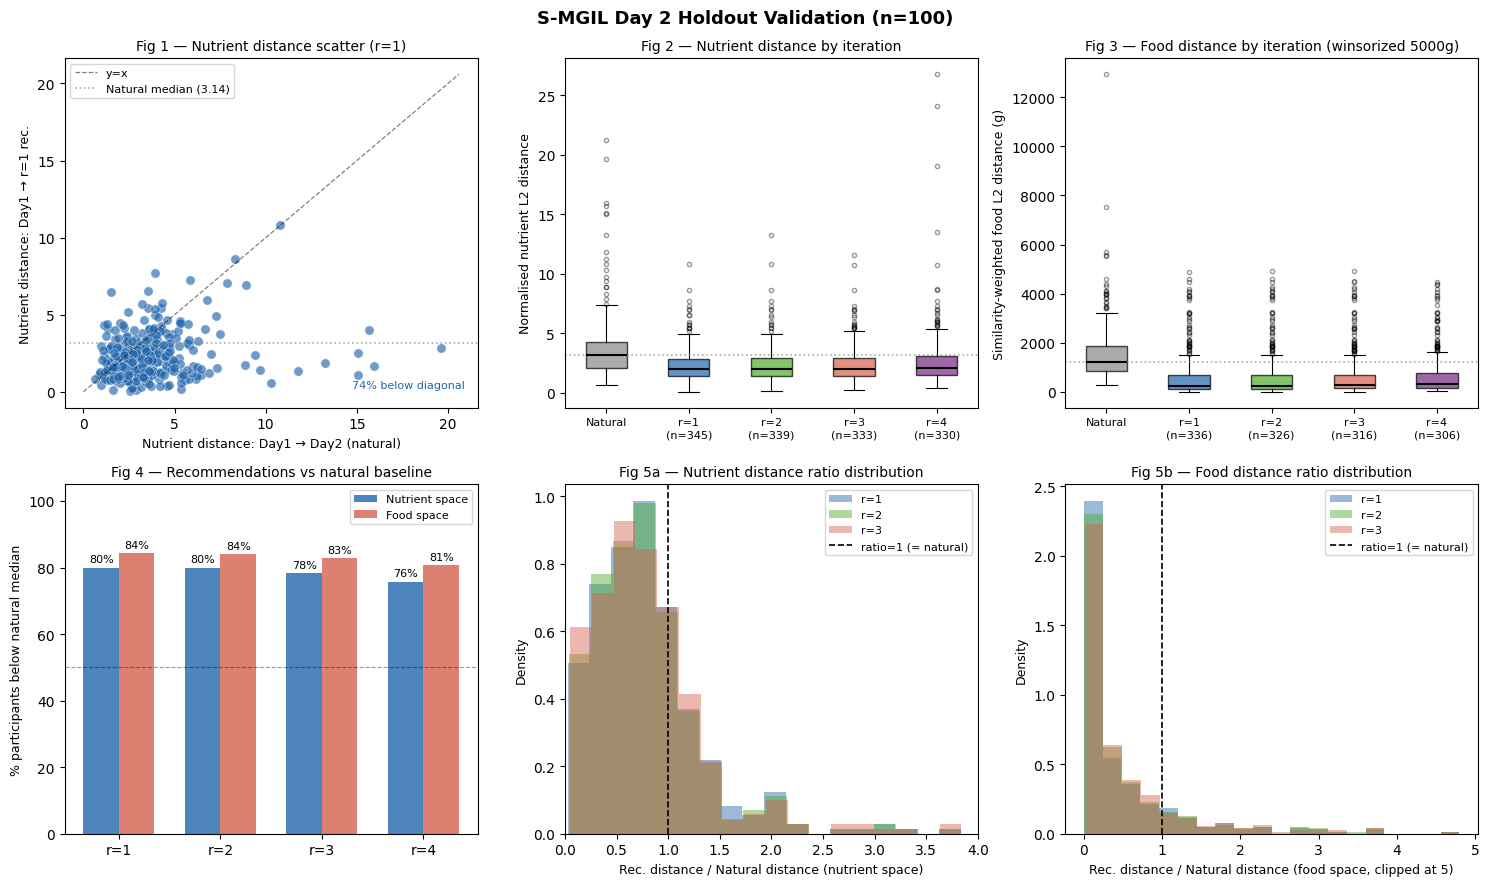

Saved.


In [30]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

df = pd.read_csv('smgil_day2_validation.csv')

FOOD_CAP = 5000
for col in [c for c in df.columns if c.startswith('d_food_r')]:
    df[col] = df[col].where(df[col] < FOOD_CAP)

nat_nut_med  = df['d_nut_natural'].median()
nat_food_med = df['d_food_natural'].median()

COLORS = {
    'natural': '#888888',
    'r1': '#2166ac',
    'r2': '#4dac26',
    'r3': '#d6604d',
    'r4': '#762a83',
}
LABELS = {
    'natural': 'Natural (Day1→Day2)',
    'r1': 'r=1', 'r2': 'r=2', 'r3': 'r=3', 'r4': 'r=4',
}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('S-MGIL Day 2 Holdout Validation (n=100)', fontsize=13, fontweight='bold', y=0.98)

# ── Figure 1: Nutrient distance scatter (natural vs r=1) ──────────────────
ax = axes[0, 0]
merged = df[['d_nut_natural', 'd_nut_r1']].dropna()
ax.scatter(merged['d_nut_natural'], merged['d_nut_r1'],
           alpha=0.65, color=COLORS['r1'], edgecolors='white', linewidths=0.4, s=45)
lim = max(merged['d_nut_natural'].max(), merged['d_nut_r1'].max()) * 1.05
ax.plot([0, lim], [0, lim], 'k--', lw=0.9, alpha=0.5, label='y=x')
ax.axhline(nat_nut_med, color=COLORS['natural'], lw=1.2, ls=':', alpha=0.7,
           label=f'Natural median ({nat_nut_med:.2f})')
ax.set_xlabel('Nutrient distance: Day1 → Day2 (natural)', fontsize=9)
ax.set_ylabel('Nutrient distance: Day1 → r=1 rec.', fontsize=9)
ax.set_title('Fig 1 — Nutrient distance scatter (r=1)', fontsize=10)
ax.legend(fontsize=8)
pct = 100 * (merged['d_nut_r1'] < merged['d_nut_natural']).mean()
ax.text(0.97, 0.05, f'{pct:.0f}% below diagonal', ha='right', va='bottom',
        transform=ax.transAxes, fontsize=8, color=COLORS['r1'])

# ── Figure 2: Nutrient distance boxplot across r ─────────────────────────
ax = axes[0, 1]
nut_data = [df['d_nut_natural'].dropna().values]
nut_labels = ['Natural']
nut_colors = [COLORS['natural']]
for r in [1, 2, 3, 4]:
    col = f'd_nut_r{r}'
    if col in df.columns:
        nut_data.append(df[col].dropna().values)
        nut_labels.append(f'r={r}\n(n={len(df[col].dropna())})')
        nut_colors.append(COLORS[f'r{r}'])

bp = ax.boxplot(nut_data, patch_artist=True, medianprops=dict(color='black', lw=1.5),
                whiskerprops=dict(lw=0.8), capprops=dict(lw=0.8),
                flierprops=dict(marker='o', markersize=3, alpha=0.4))
for patch, color in zip(bp['boxes'], nut_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.axhline(nat_nut_med, color=COLORS['natural'], lw=1.2, ls=':', alpha=0.7)
ax.set_xticklabels(nut_labels, fontsize=8)
ax.set_ylabel('Normalised nutrient L2 distance', fontsize=9)
ax.set_title('Fig 2 — Nutrient distance by iteration', fontsize=10)

# ── Figure 3: Food distance boxplot across r ─────────────────────────────
ax = axes[0, 2]
food_data = [df['d_food_natural'].dropna().values]
food_labels = ['Natural']
food_colors = [COLORS['natural']]
for r in [1, 2, 3, 4]:
    col = f'd_food_r{r}'
    if col in df.columns:
        s = df[col].dropna()
        food_data.append(s.values)
        food_labels.append(f'r={r}\n(n={len(s)})')
        food_colors.append(COLORS[f'r{r}'])

bp = ax.boxplot(food_data, patch_artist=True, medianprops=dict(color='black', lw=1.5),
                whiskerprops=dict(lw=0.8), capprops=dict(lw=0.8),
                flierprops=dict(marker='o', markersize=3, alpha=0.4))
for patch, color in zip(bp['boxes'], food_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.axhline(nat_food_med, color=COLORS['natural'], lw=1.2, ls=':', alpha=0.7)
ax.set_xticklabels(food_labels, fontsize=8)
ax.set_ylabel('Similarity-weighted food L2 distance (g)', fontsize=9)
ax.set_title('Fig 3 — Food distance by iteration (winsorized 5000g)', fontsize=10)

# ── Figure 4: % below natural median bar chart ───────────────────────────
ax = axes[1, 0]
rs = [1, 2, 3, 4]
pct_nut  = []
pct_food = []
for r in rs:
    nc = f'd_nut_r{r}'
    fc = f'd_food_r{r}'
    if nc in df.columns:
        s = df[nc].dropna()
        pct_nut.append(100 * (s < nat_nut_med).mean())
    else:
        pct_nut.append(np.nan)
    if fc in df.columns:
        s = df[fc].dropna()
        pct_food.append(100 * (s < nat_food_med).mean())
    else:
        pct_food.append(np.nan)

x = np.arange(len(rs))
w = 0.35
bars1 = ax.bar(x - w/2, pct_nut,  w, label='Nutrient space', color='#2166ac', alpha=0.8)
bars2 = ax.bar(x + w/2, pct_food, w, label='Food space',     color='#d6604d', alpha=0.8)
ax.axhline(50, color='black', lw=0.8, ls='--', alpha=0.4)
ax.set_xticks(x)
ax.set_xticklabels([f'r={r}' for r in rs])
ax.set_ylabel('% participants below natural median', fontsize=9)
ax.set_ylim(0, 105)
ax.set_title('Fig 4 — Recommendations vs natural baseline', fontsize=10)
ax.legend(fontsize=8)
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.0f}%', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.0f}%', ha='center', va='bottom', fontsize=8)

# ── Figure 5: Ratio histograms (rec / natural), nutrient space ───────────
ax = axes[1, 1]
for r, color in [(1, COLORS['r1']), (2, COLORS['r2']), (3, COLORS['r3'])]:
    nc = f'd_nut_r{r}'
    fc = 'd_nut_natural'
    merged = df[[nc, fc]].dropna()
    ratio = merged[nc] / merged[fc]
    ax.hist(ratio, bins=20, alpha=0.45, color=color, label=f'r={r}', density=True)
ax.axvline(1.0, color='black', lw=1.2, ls='--', label='ratio=1 (= natural)')
ax.set_xlabel('Rec. distance / Natural distance (nutrient space)', fontsize=9)
ax.set_ylabel('Density', fontsize=9)
ax.set_title('Fig 5a — Nutrient distance ratio distribution', fontsize=10)
ax.legend(fontsize=8)
ax.set_xlim(0, 4)

# ── Figure 6: Ratio histograms, food space ───────────────────────────────
ax = axes[1, 2]
for r, color in [(1, COLORS['r1']), (2, COLORS['r2']), (3, COLORS['r3'])]:
    fc_rec = f'd_food_r{r}'
    fc_nat = 'd_food_natural'
    merged = df[[fc_rec, fc_nat]].dropna()
    ratio = merged[fc_rec] / merged[fc_nat]
    ratio = ratio[ratio < 5]  # clip extreme ratios for display
    ax.hist(ratio, bins=20, alpha=0.45, color=color, label=f'r={r}', density=True)
ax.axvline(1.0, color='black', lw=1.2, ls='--', label='ratio=1 (= natural)')
ax.set_xlabel('Rec. distance / Natural distance (food space, clipped at 5)', fontsize=9)
ax.set_ylabel('Density', fontsize=9)
ax.set_title('Fig 5b — Food distance ratio distribution', fontsize=10)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('smgil_validation_figures_scaled.pdf', bbox_inches='tight', dpi=200)
plt.savefig('smgil_validation_figures_scaled.png', bbox_inches='tight', dpi=200)
plt.show()
print("Saved.")

In [31]:
from scipy import stats

print("=== Wilcoxon Signed-Rank Test ===")
print("H0: rec distance >= natural distance")
print("H1: rec distance < natural distance (one-sided)\n")

for metric, label in [('d_nut', 'Nutrient space'), ('d_food', 'Food space (winsorized)')]:
    print(f"── {label} ──")
    nat_col = f'{metric}_natural'
    for r in [1, 2, 3, 4]:
        rec_col = f'{metric}_r{r}'
        if rec_col not in df.columns:
            continue
        merged = df[[nat_col, rec_col]].dropna()
        if len(merged) < 10:
            continue
        stat, p = stats.wilcoxon(merged[rec_col], merged[nat_col],
                                  alternative='less')
        n = len(merged)
        med_rec = merged[rec_col].median()
        med_nat = merged[nat_col].median()
        print(f"  r={r} (n={n}): median rec={med_rec:.3f}, median nat={med_nat:.3f}, "
              f"W={stat:.1f}, p={p:.2e}")
    print()

=== Wilcoxon Signed-Rank Test ===
H0: rec distance >= natural distance
H1: rec distance < natural distance (one-sided)

── Nutrient space ──
  r=1 (n=345): median rec=1.991, median nat=3.144, W=11055.0, p=1.95e-24
  r=2 (n=339): median rec=1.998, median nat=3.142, W=10694.0, p=5.35e-24
  r=3 (n=333): median rec=2.009, median nat=3.126, W=11101.0, p=1.04e-21
  r=4 (n=330): median rec=2.062, median nat=3.143, W=13297.0, p=3.30e-16

── Food space (winsorized) ──
  r=1 (n=336): median rec=237.978, median nat=1212.767, W=7150.0, p=8.10e-33
  r=2 (n=326): median rec=257.756, median nat=1233.140, W=6840.0, p=1.41e-31
  r=3 (n=316): median rec=285.465, median nat=1233.140, W=6777.0, p=1.33e-29
  r=4 (n=306): median rec=329.234, median nat=1254.312, W=7525.0, p=3.39e-25



# HTML

In [32]:
"""
generate_dashboard.py  (v4)
---------------------------
Nutrient totals come ENTIRELY from smgil_all_diets.csv (reliable,
since both day1_to_rows and rec_to_rows store per-item nutrients keyed
by NUTRIENT_COLS_CSV). No positional constraint_names assumption needed.

Nutrient tab replaced with a 2×5 subplot grid — one panel per nutrient,
each with its own y-axis and DASH bound line.
"""

import json
import pandas as pd
import numpy as np

SUMMARY_CSV = 'smgil_day2_validation.csv'
DIETS_CSV   = 'smgil_all_diets.csv'
OUT_HTML    = 'smgil_dashboard.html'

NUTRIENT_COLS = [
    'sodium_mg', 'total_saturated_fatty_acids_gm', 'total_sugars_gm',
    'cholesterol_mg', 'total_fat_gm', 'dietary_fiber_gm',
    'potassium_mg', 'calcium_mg', 'magnesium_mg', 'protein_gm',
]
NUTRIENT_LABELS = {
    'sodium_mg':                      'Sodium (mg)',
    'total_saturated_fatty_acids_gm': 'Sat. Fat (g)',
    'total_sugars_gm':                'Sugars (g)',
    'cholesterol_mg':                 'Cholesterol (mg)',
    'total_fat_gm':                   'Total Fat (g)',
    'dietary_fiber_gm':               'Fiber (g)',
    'potassium_mg':                   'Potassium (mg)',
    'calcium_mg':                     'Calcium (mg)',
    'magnesium_mg':                   'Magnesium (mg)',
    'protein_gm':                     'Protein (g)',
}
DASH_BOUNDS = {
    'sodium_mg':                      {'ub': 2300,  'lb': None},
    'total_saturated_fatty_acids_gm': {'ub': 22,    'lb': None},
    'total_sugars_gm':                {'ub': 100,   'lb': None},
    'cholesterol_mg':                 {'ub': 150,   'lb': None},
    'total_fat_gm':                   {'ub': 65,    'lb': None},
    'dietary_fiber_gm':               {'ub': None,  'lb': 25},
    'potassium_mg':                   {'ub': None,  'lb': 4700},
    'calcium_mg':                     {'ub': None,  'lb': 1200},
    'magnesium_mg':                   {'ub': None,  'lb': 320},
    'protein_gm':                     {'ub': None,  'lb': 46},
}
DIET_ORDER  = ['day1', 'rec_r1', 'rec_r2', 'rec_r3', 'rec_r4', 'day2']
DIET_LABELS = {
    'day1':   'Day 1 (Observed)',
    'rec_r1': 'Rec r=1',
    'rec_r2': 'Rec r=2',
    'rec_r3': 'Rec r=3',
    'rec_r4': 'Rec r=4',
    'day2':   'Day 2 (Actual)',
}
DIET_COLORS = {
    'day1':   '#4a6fa5',
    'rec_r1': '#2a9d8f',
    'rec_r2': '#52b788',
    'rec_r3': '#74c69d',
    'rec_r4': '#95d5b2',
    'day2':   '#e76f51',
}

# ── Load ─────────────────────────────────────────────────────────
df_s = pd.read_csv(SUMMARY_CSV)
df_d = pd.read_csv(DIETS_CSV)
df_s['pid'] = df_s['pid'].astype(int)
df_d['pid'] = df_d['pid'].astype(int)

for c in NUTRIENT_COLS:
    if c not in df_d.columns:
        df_d[c] = 0.0
    df_d[c] = df_d[c].fillna(0.0)

# Pre-compute nutrient totals per (pid, diet_type) straight from diets CSV
# This avoids ALL constraint_names ordering assumptions
nut_totals_df = (
    df_d.groupby(['pid', 'diet_type'])[NUTRIENT_COLS]
    .sum()
    .reset_index()
)

def get_totals(pid, dt):
    row = nut_totals_df[
        (nut_totals_df['pid'] == pid) &
        (nut_totals_df['diet_type'] == dt)
    ]
    if row.empty:
        return {nc: 0.0 for nc in NUTRIENT_COLS}
    return {nc: round(float(row.iloc[0][nc]), 2) for nc in NUTRIENT_COLS}

# ── Build payload ─────────────────────────────────────────────────
participants = []

for _, row in df_s.iterrows():
    pid    = int(row['pid'])
    n_iter = int(row.get('n_iter', 0))
    cov    = float(row.get('coverage_day2', 0))

    dist = {}
    for k in ['d_nut_natural', 'd_food_natural']:
        dist[k] = round(float(row[k]), 4) if k in row and not pd.isna(row[k]) else None
    for r in range(1, 5):
        for m in ['d_nut', 'd_food']:
            k = f'{m}_r{r}'
            dist[k] = round(float(row[k]), 4) if k in row and not pd.isna(row[k]) else None
        tk = f'tight_r{r}'
        dist[f'tight_r{r}'] = str(row[tk]) if tk in row and not pd.isna(row[tk]) else ''

    pid_d = df_d[df_d['pid'] == pid]
    diets = {}
    for dt in DIET_ORDER:
        sub = pid_d[pid_d['diet_type'] == dt]
        if sub.empty:
            continue
        foods = []
        for _, fr in sub.sort_values('grams', ascending=False).iterrows():
            entry = {'food_name': str(fr.get('food_name', '')),
                     'grams': round(float(fr.get('grams', 0)), 1)}
            for nc in NUTRIENT_COLS:
                entry[nc] = round(float(fr.get(nc, 0)), 2)
            foods.append(entry)
        # Totals summed directly from diets CSV — no positional assumption
        diets[dt] = {'foods': foods, 'totals': get_totals(pid, dt)}

    participants.append({
        'pid': pid, 'n_iter': n_iter, 'coverage': round(cov, 3),
        'distances': dist, 'diets': diets,
    })

payload = json.dumps(participants, allow_nan=False)

# ── HTML ──────────────────────────────────────────────────────────
html = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8"/>
<meta name="viewport" content="width=device-width,initial-scale=1.0"/>
<title>S-MGIL Diet Recommendation Explorer</title>
<script src="https://cdn.plot.ly/plotly-2.27.0.min.js"></script>
<link href="https://fonts.googleapis.com/css2?family=IBM+Plex+Mono:wght@400;600&family=IBM+Plex+Sans:wght@300;400;600&display=swap" rel="stylesheet"/>
<style>
*,*::before,*::after{{box-sizing:border-box;margin:0;padding:0}}
:root{{
  --bg:#f5f2ed;--surf:#ffffff;--sb:#0f1e2e;--sbw:260px;
  --navy:#0f1e2e;--teal:#2a9d8f;--amber:#e9c46a;--coral:#e76f51;--sage:#52a788;
  --text:#1a1a2e;--muted:#6b7280;--border:#e2ddd6;
  --mono:'IBM Plex Mono',monospace;--sans:'IBM Plex Sans',sans-serif;--r:8px;
}}
body{{font-family:var(--sans);background:var(--bg);color:var(--text);
      display:flex;height:100vh;overflow:hidden}}

/* Sidebar */
#sb{{width:var(--sbw);min-width:var(--sbw);background:var(--sb);
     display:flex;flex-direction:column;overflow:hidden;border-right:1px solid #1e3a54}}
#sb-hd{{padding:20px 16px 12px;border-bottom:1px solid #1e3a54}}
#sb-hd h1{{font-size:11px;font-weight:600;letter-spacing:.14em;text-transform:uppercase;color:var(--teal);margin-bottom:2px}}
#sb-hd p{{font-size:11px;color:#6b8aaa;font-weight:300}}
#srch-w{{padding:9px 12px;border-bottom:1px solid #1e3a54}}
#srch{{width:100%;background:#1a3148;border:1px solid #2a4a6a;border-radius:5px;
       color:#c8daea;font-family:var(--mono);font-size:12px;padding:6px 10px;outline:none}}
#srch::placeholder{{color:#4a6a8a}} #srch:focus{{border-color:var(--teal)}}
#pid-list{{flex:1;overflow-y:auto;padding:5px 0}}
#pid-list::-webkit-scrollbar{{width:3px}}
#pid-list::-webkit-scrollbar-thumb{{background:#2a4a6a;border-radius:2px}}
.pi{{padding:7px 16px;cursor:pointer;display:flex;align-items:center;gap:8px;
     transition:background .1s;border-left:3px solid transparent}}
.pi:hover{{background:#1a3148}} .pi.active{{background:#1a3148;border-left-color:var(--teal)}}
.pn{{font-family:var(--mono);font-size:12px;color:#c8daea;font-weight:600}}
.pb{{font-size:10px;font-family:var(--mono);padding:2px 6px;border-radius:3px;font-weight:600;margin-left:auto}}
.pb.am{{background:#1a4a3a;color:var(--teal)}} .pb.na{{background:#3a2a1a;color:var(--amber)}}
#sb-ft{{padding:9px 16px;border-top:1px solid #1e3a54;font-size:10px;color:#4a6a8a;font-family:var(--mono)}}

/* Main */
#main{{flex:1;display:flex;flex-direction:column;overflow:hidden}}
#topbar{{background:var(--surf);border-bottom:1px solid var(--border);
         padding:11px 22px;display:flex;align-items:center;gap:14px;flex-shrink:0;flex-wrap:wrap}}
#tb-pid{{font-family:var(--mono);font-size:17px;font-weight:600;color:var(--navy)}}
.sc .sl{{font-size:9px;font-weight:600;letter-spacing:.1em;text-transform:uppercase;color:var(--muted)}}
.sc .sv{{font-family:var(--mono);font-size:13px;font-weight:600;color:var(--navy)}}
.sv.good{{color:var(--sage)}} .sv.warn{{color:var(--coral)}}
.dvdr{{width:1px;height:26px;background:var(--border);flex-shrink:0}}

/* Page tabs */
#tabs{{display:flex;border-bottom:1px solid var(--border);background:var(--surf);
       flex-shrink:0;padding:0 22px}}
.tab{{padding:8px 15px;font-size:11px;font-weight:600;letter-spacing:.07em;text-transform:uppercase;
      cursor:pointer;color:var(--muted);border-bottom:2px solid transparent;
      transition:all .15s;white-space:nowrap}}
.tab:hover{{color:var(--navy)}} .tab.active{{color:var(--teal);border-bottom-color:var(--teal)}}

/* Content */
#content{{flex:1;overflow-y:auto;padding:18px 22px;display:flex;flex-direction:column;gap:14px;min-height:0}}
#content::-webkit-scrollbar{{width:5px}}
#content::-webkit-scrollbar-thumb{{background:var(--border);border-radius:3px}}

/* Cards */
.card{{background:var(--surf);border:1px solid var(--border);border-radius:var(--r);overflow:hidden;flex-shrink:0}}
.ch{{padding:11px 16px 8px;border-bottom:1px solid var(--border)}}
.ch h3{{font-size:10px;font-weight:600;letter-spacing:.1em;text-transform:uppercase;color:var(--muted)}}

/* Distance cards */
#dr{{display:grid;grid-template-columns:repeat(auto-fill,minmax(145px,1fr));gap:10px}}
.dc{{background:var(--surf);border:1px solid var(--border);border-radius:var(--r);padding:11px 13px}}
.dcl{{font-size:9px;font-weight:600;letter-spacing:.09em;text-transform:uppercase;color:var(--muted);margin-bottom:2px}}
.dcv{{font-family:var(--mono);font-size:19px;font-weight:600;color:var(--navy)}}
.dcs{{font-size:9px;color:var(--muted);margin-top:2px;font-family:var(--mono)}}
.dc-nat{{border-left:3px solid var(--coral)}}
.dc-r1{{border-left:3px solid #2a9d8f}} .dc-r2{{border-left:3px solid #52b788}}
.dc-r3{{border-left:3px solid #74c69d}} .dc-r4{{border-left:3px solid #95d5b2}}

/* Tight chips */
.tc{{background:#eef6f4;border:1px solid #b8ddd6;color:#1a6655;font-size:10px;font-family:var(--mono);padding:2px 9px;border-radius:20px}}

/* Diet sub-tabs */
.dtabs{{display:flex;border-bottom:1px solid var(--border);padding:0 16px;overflow-x:auto;flex-shrink:0}}
.dtabs::-webkit-scrollbar{{height:3px}}
.dtab{{padding:7px 12px;font-size:11px;font-weight:600;cursor:pointer;color:var(--muted);
       border-bottom:2px solid transparent;transition:all .15s;white-space:nowrap;flex-shrink:0}}
.dtab:hover{{color:var(--navy)}} .dtab.active{{color:var(--navy)}}

/* Tables */
.tw{{overflow-x:auto;overflow-y:auto;max-height:420px}}
.tw::-webkit-scrollbar{{width:4px;height:4px}}
.tw::-webkit-scrollbar-thumb{{background:var(--border);border-radius:2px}}
table.ft{{width:100%;border-collapse:collapse;font-size:11px}}
table.ft thead{{position:sticky;top:0;z-index:1;background:var(--surf)}}
table.ft th{{text-align:left;font-size:9px;font-weight:600;letter-spacing:.08em;text-transform:uppercase;
             color:var(--muted);padding:8px 8px 5px;border-bottom:2px solid var(--border);white-space:nowrap}}
table.ft td{{padding:5px 8px;border-bottom:1px solid #f0ece6;font-family:var(--mono);font-size:11px;white-space:nowrap}}
table.ft td.fn{{font-family:var(--sans);font-size:11px;color:var(--navy);white-space:normal;min-width:160px;max-width:220px}}
table.ft tr.tr-tot td{{background:#f8f5f0;font-weight:600;border-top:2px solid var(--border)}}
table.ft tbody tr:hover td{{background:#faf8f5}}
.exc{{color:var(--coral)}} .ok{{color:var(--sage)}}

/* Nutrient bars */
.nb-wrap{{height:6px;background:#eee;border-radius:3px;overflow:hidden;margin-top:2px}}
.nb-fill{{height:100%;border-radius:3px;transition:width .4s ease}}

/* Food comparison */
.diff-leg{{display:flex;flex-wrap:wrap;gap:10px;padding:10px 16px 6px;font-size:10px;color:var(--muted)}}
.dl{{display:inline-block;width:10px;height:10px;border-radius:2px;margin-right:3px;vertical-align:middle}}
table.diff-t{{width:100%;border-collapse:collapse;font-size:11px}}
table.diff-t thead th{{text-align:center;font-size:9px;font-weight:600;letter-spacing:.07em;text-transform:uppercase;
  color:var(--muted);padding:8px 8px 5px;border-bottom:2px solid var(--border);
  white-space:nowrap;position:sticky;top:0;background:var(--surf)}}
table.diff-t thead th:first-child{{text-align:left;padding-left:14px}}
table.diff-t td{{padding:5px 8px;border-bottom:1px solid #f0ece6;font-family:var(--mono);font-size:11px;text-align:center}}
table.diff-t td.fc{{font-family:var(--sans);font-size:11px;color:var(--navy);text-align:left;
                    padding-left:14px;white-space:normal;min-width:160px;max-width:220px}}
table.diff-t tbody tr:hover td{{background:#faf8f5}}
.d-base{{color:#4a6fa5;font-weight:600}}
.d-dec{{color:#1a6655;background:#eef6f4;border-radius:3px;padding:1px 5px}}
.d-inc{{color:#9a3a20;background:#fef3ee;border-radius:3px;padding:1px 5px}}
.d-new{{color:#0f4c6a;background:#e0f0fa;border-radius:3px;padding:1px 5px}}
.d-gone{{color:#bbb;font-style:italic}}
.d-d2{{color:#8b4513;background:#fff3ee;border-radius:3px;padding:1px 5px}}
.d-zero{{color:#ddd}}

/* Swap summary */
.sw-iter{{padding:10px 16px;border-bottom:1px solid var(--border)}}
.sw-iter:last-child{{border-bottom:none}}
.sw-head{{font-family:var(--mono);font-size:11px;font-weight:600;color:var(--teal);margin-bottom:6px}}
.sw-lbl{{font-size:9px;font-weight:600;letter-spacing:.09em;text-transform:uppercase;color:var(--muted);margin-bottom:4px}}
.chip-dec{{display:inline-block;font-size:10px;color:#1a6655;background:#eef6f4;padding:2px 8px;border-radius:3px;margin:2px 3px 2px 0}}
.chip-inc{{display:inline-block;font-size:10px;color:#9a3a20;background:#fef3ee;padding:2px 8px;border-radius:3px;margin:2px 3px 2px 0}}
.chip-new{{display:inline-block;font-size:10px;color:#0f4c6a;background:#e0f0fa;padding:2px 8px;border-radius:3px;margin:2px 3px 2px 0}}

/* Nutrient subplot grid */
.nut-grid{{display:grid;grid-template-columns:repeat(5,1fr);gap:1px;background:var(--border);
           margin:0;overflow:hidden;border-radius:0 0 var(--r) var(--r)}}
.nut-cell{{background:var(--surf);padding:0}}

/* Chart */
.cw{{width:100%;min-height:260px}}

/* Ratio chips */
.rc{{border-radius:8px;padding:10px 14px;min-width:110px;display:inline-block}}

/* Empty */
#empty{{flex:1;display:flex;flex-direction:column;align-items:center;justify-content:center;color:var(--muted);gap:8px}}
#empty .big{{font-size:44px}}
</style>
</head>
<body>

<div id="sb">
  <div id="sb-hd"><h1>S-MGIL Explorer</h1><p>NHANES Dietary Recommendations</p></div>
  <div id="srch-w"><input id="srch" type="text" placeholder="Search PID…"/></div>
  <div id="pid-list"></div>
  <div id="sb-ft">Loading…</div>
</div>

<div id="main">
  <div id="topbar"><span id="tb-pid" style="color:#999">← Select a participant</span></div>
  <div id="tabs" style="display:none">
    <div class="tab active" data-tab="overview">Overview</div>
    <div class="tab" data-tab="foods">Food Tables</div>
    <div class="tab" data-tab="comparison">Food Comparison</div>
    <div class="tab" data-tab="nutrients">Nutrients</div>
    <div class="tab" data-tab="distances">Distances</div>
  </div>
  <div id="content">
    <div id="empty"><div class="big">🥗</div><p>Select a participant from the sidebar.</p></div>
  </div>
</div>

<script>
const PARTICIPANTS = {payload};
const NUT_LABELS  = {json.dumps(NUTRIENT_LABELS)};
const DASH_BOUNDS = {json.dumps(DASH_BOUNDS)};
const DIET_ORDER  = {json.dumps(DIET_ORDER)};
const DIET_LABELS = {json.dumps(DIET_LABELS)};
const DIET_COLORS = {json.dumps(DIET_COLORS)};
const NUT_KEYS    = {json.dumps(NUTRIENT_COLS)};

let curPid=null, curTab='overview', curDiet='day1';
const byPid={{}};
PARTICIPANTS.forEach(p=>byPid[p.pid]=p);

// ── Sidebar ───────────────────────────────────────────────────
function buildSB(f=''){{
  const l=document.getElementById('pid-list'); l.innerHTML='';
  PARTICIPANTS.filter(p=>String(p.pid).includes(f.toLowerCase())).forEach(p=>{{
    const d=document.createElement('div');
    d.className='pi'+(p.pid===curPid?' active':'');
    d.dataset.pid=p.pid;
    const am=p.n_iter>0;
    d.innerHTML=`<span class="pn">${{p.pid}}</span>
      <span class="pb ${{am?'am':'na'}}">${{am?'r='+p.n_iter:'N/A'}}</span>`;
    d.addEventListener('click',()=>select(p.pid));
    l.appendChild(d);
  }});
}}
document.getElementById('srch').addEventListener('input',e=>buildSB(e.target.value));

function select(pid){{
  curPid=pid; curDiet='day1';
  document.querySelectorAll('.pi').forEach(e=>e.classList.toggle('active',parseInt(e.dataset.pid)===pid));
  const p=byPid[pid];
  document.getElementById('topbar').innerHTML=topbarHTML(p);
  document.getElementById('tabs').style.display='flex';
  setTab(curTab);
}}

function topbarHTML(p){{
  const d=p.distances;
  const nat=d.d_nut_natural!=null?d.d_nut_natural.toFixed(3):'—';
  const r1=d.d_nut_r1!=null?d.d_nut_r1.toFixed(3):'—';
  const better=d.d_nut_r1!=null&&d.d_nut_natural!=null&&d.d_nut_r1<d.d_nut_natural;
  return `<span id="tb-pid">PID ${{p.pid}}</span>
    <div class="dvdr"></div>
    <div class="sc"><span class="sl">Iterations</span>
      <span class="sv ${{p.n_iter>0?'good':'warn'}}">${{p.n_iter>0?p.n_iter:'Non-amenable'}}</span></div>
    <div class="dvdr"></div>
    <div class="sc"><span class="sl">Day 2 Coverage</span>
      <span class="sv">${{(p.coverage*100).toFixed(0)}}%</span></div>
    <div class="dvdr"></div>
    <div class="sc"><span class="sl">Natural Dist (nut)</span><span class="sv">${{nat}}</span></div>
    <div class="dvdr"></div>
    <div class="sc"><span class="sl">Rec r=1 (nut)</span>
      <span class="sv ${{better?'good':''}}">${{r1}}</span></div>`;
}}

document.querySelectorAll('.tab').forEach(t=>t.addEventListener('click',()=>setTab(t.dataset.tab)));
function setTab(tab){{
  curTab=tab;
  document.querySelectorAll('.tab').forEach(t=>t.classList.toggle('active',t.dataset.tab===tab));
  const p=byPid[curPid], c=document.getElementById('content');
  c.innerHTML='';
  if     (tab==='overview')   renderOverview(p,c);
  else if(tab==='foods')      renderFoods(p,c);
  else if(tab==='comparison') renderComparison(p,c);
  else if(tab==='nutrients')  renderNutrients(p,c);
  else if(tab==='distances')  renderDistances(p,c);
}}

function mkCard(title){{
  const c=document.createElement('div'); c.className='card';
  if(title){{ const h=document.createElement('div'); h.className='ch';
    h.innerHTML=`<h3>${{title}}</h3>`; c.appendChild(h); }}
  return c;
}}
function safe(v,dec=1){{ return (v!=null&&!isNaN(v))?Number(v).toFixed(dec):'—'; }}

// ── OVERVIEW ─────────────────────────────────────────────────
function renderOverview(p,el){{
  const d=p.distances;
  const dr=document.createElement('div'); dr.id='dr';
  let h=`<div class="dc dc-nat"><div class="dcl">Natural Day1→Day2</div>
    <div class="dcv">${{safe(d.d_nut_natural,3)}}</div>
    <div class="dcs">Nutrient dist</div></div>`;
  for(let r=1;r<=4;r++){{
    const v=d[`d_nut_r${{r}}`]; if(v==null)continue;
    const better=d.d_nut_natural!=null&&v<d.d_nut_natural;
    h+=`<div class="dc dc-r${{r}}"><div class="dcl">Rec r=${{r}}</div>
      <div class="dcv" style="color:${{better?'#2a9d8f':'#e76f51'}}">${{v.toFixed(3)}}</div>
      <div class="dcs">${{better?'▼ within natural':'▲ exceeds natural'}}</div></div>`;
  }}
  dr.innerHTML=h; el.appendChild(dr);

  if([1,2,3,4].some(r=>d[`tight_r${{r}}`])){{
    const card=mkCard('Tight Constraints by Iteration');
    const body=document.createElement('div'); body.style.paddingBottom='10px';
    for(let r=1;r<=4;r++){{
      const t=d[`tight_r${{r}}`]; if(!t)continue;
      const row=document.createElement('div');
      row.style.cssText='display:flex;align-items:baseline;gap:8px;padding:4px 16px';
      row.innerHTML=`<span style="font-family:var(--mono);font-size:11px;font-weight:600;color:var(--teal);min-width:34px">r=${{r}}</span>`;
      const chips=document.createElement('div'); chips.style.cssText='display:flex;flex-wrap:wrap;gap:4px';
      t.split(',').map(s=>s.trim()).filter(Boolean).forEach(c=>{{
        const ch=document.createElement('span'); ch.className='tc'; ch.textContent=c; chips.appendChild(ch);
      }});
      row.appendChild(chips); body.appendChild(row);
    }}
    card.appendChild(body); el.appendChild(card);
  }}

  const card=mkCard('Nutrient Distance: Recommendations vs Natural Baseline');
  const cd=document.createElement('div'); cd.className='cw'; cd.style.height='230px';
  card.appendChild(cd); el.appendChild(card);
  const labs=[],vals=[],cols=[];
  labs.push('Natural'); vals.push(d.d_nut_natural); cols.push('#e76f51');
  for(let r=1;r<=4;r++){{
    if(d[`d_nut_r${{r}}`]==null)continue;
    labs.push(`Rec r=${{r}}`); vals.push(d[`d_nut_r${{r}}`]); cols.push(DIET_COLORS[`rec_r${{r}}`]);
  }}
  setTimeout(()=>Plotly.newPlot(cd,
    [{{type:'bar',x:labs,y:vals.map(v=>v||0),marker:{{color:cols}},
       hovertemplate:'<b>%{{x}}</b><br>%{{y:.4f}}<extra></extra>'}}],
    {{margin:{{l:10,r:10,t:10,b:30}},paper_bgcolor:'transparent',plot_bgcolor:'transparent',
      xaxis:{{showgrid:false,tickfont:{{family:'IBM Plex Mono',size:11}}}},
      yaxis:{{showgrid:true,gridcolor:'#f0ece6',tickfont:{{family:'IBM Plex Mono',size:11}}}},
      showlegend:false,
      shapes:d.d_nut_natural!=null?[{{type:'line',x0:-.5,x1:labs.length-.5,
        y0:d.d_nut_natural,y1:d.d_nut_natural,line:{{color:'#e76f51',width:1.5,dash:'dot'}}}}]:[]}},
    {{responsive:true,displayModeBar:false}}),0);
}}

// ── FOOD TABLES ───────────────────────────────────────────────
function renderFoods(p,el){{
  el.innerHTML='';
  const avail=DIET_ORDER.filter(dt=>p.diets[dt]);
  if(!avail.length){{el.innerHTML='<p style="padding:20px;color:var(--muted)">No food data.</p>';return;}}

  const card=mkCard('Food Composition by Diet Type');
  const tbBar=document.createElement('div'); tbBar.className='dtabs';
  avail.forEach(dt=>{{
    const t=document.createElement('div');
    t.className='dtab'+(dt===curDiet?' active':'');
    t.dataset.dt=dt;
    t.style.borderBottomColor=dt===curDiet?DIET_COLORS[dt]:'transparent';
    t.textContent=DIET_LABELS[dt]||dt;
    t.addEventListener('click',()=>{{curDiet=dt;renderFoods(p,el);}});
    tbBar.appendChild(t);
  }});
  card.appendChild(tbBar);

  const diet=p.diets[curDiet];
  const tw=document.createElement('div'); tw.className='tw';
  let html=`<table class="ft"><thead><tr><th style="min-width:160px">Food Item</th><th>Grams</th>`;
  NUT_KEYS.forEach(nc=>{{html+=`<th>${{NUT_LABELS[nc]}}</th>`;}});
  html+=`</tr></thead><tbody>`;
  diet.foods.forEach(f=>{{
    html+=`<tr><td class="fn">${{f.food_name}}</td><td>${{safe(f.grams,1)}}</td>`;
    NUT_KEYS.forEach(nc=>{{html+=`<td>${{safe(f[nc]||0,1)}}</td>`;}});
    html+=`</tr>`;
  }});
  html+=`<tr class="tr-tot"><td class="fn">TOTAL</td><td>—</td>`;
  NUT_KEYS.forEach(nc=>{{
    const tot=diet.totals[nc]||0, b=DASH_BOUNDS[nc]; let cls='';
    if(b){{if(b.ub&&tot>b.ub)cls='exc';else if(b.lb&&tot<b.lb)cls='exc';else cls='ok';}}
    html+=`<td class="${{cls}}">${{tot.toFixed(1)}}</td>`;
  }});
  html+=`</tr></tbody></table>
    <p style="font-size:10px;color:var(--muted);padding:6px 16px 10px;font-family:var(--mono)">
      <span style="color:var(--coral)">■</span> Exceeds DASH bound &nbsp;
      <span style="color:var(--sage)">■</span> Within DASH bound</p>`;
  tw.innerHTML=html; card.appendChild(tw); el.appendChild(card);

  const bc=mkCard('Nutrient Totals vs DASH Bounds');
  const bb=document.createElement('div');
  bb.style.cssText='padding:12px 16px;display:grid;grid-template-columns:1fr 1fr;gap:8px 20px';
  NUT_KEYS.forEach(nc=>{{
    const val=diet.totals[nc]||0, b=DASH_BOUNDS[nc];
    const lim=b?(b.ub||b.lb):null; if(!lim)return;
    const isUB=b.ub!=null, exceed=isUB?val>b.ub:val<b.lb;
    const pct=Math.min((val/lim)*100,100);
    const item=document.createElement('div');
    item.innerHTML=`<div style="display:flex;justify-content:space-between;margin-bottom:2px">
        <span style="font-size:11px">${{NUT_LABELS[nc]}}</span>
        <span style="font-family:var(--mono);font-size:11px;color:${{exceed?'var(--coral)':'var(--sage)'}}">
          ${{val.toFixed(0)}} / ${{isUB?'≤':'≥'}}${{lim}}</span></div>
      <div class="nb-wrap"><div class="nb-fill" style="width:${{pct}}%;background:${{exceed?'#e76f51':'#52a788'}}"></div></div>`;
    bb.appendChild(item);
  }});
  bc.appendChild(bb); el.appendChild(bc);
}}

// ── FOOD COMPARISON ───────────────────────────────────────────
function renderComparison(p,el){{
  el.innerHTML='';
  const avail=DIET_ORDER.filter(dt=>p.diets[dt]);
  if(!avail.length||!p.diets['day1']){{el.innerHTML='<p style="padding:20px;color:var(--muted)">No data.</p>';return;}}

  const card=mkCard('Food Item Comparison Across All Diets');
  const leg=document.createElement('div'); leg.className='diff-leg';
  leg.innerHTML=`
    <span><span class="dl" style="background:#4a6fa5"></span>Day 1 baseline</span>
    <span><span class="dl" style="background:#eef6f4;border:1px solid #b8ddd6"></span>Reduced ▼</span>
    <span><span class="dl" style="background:#fef3ee;border:1px solid #f5c6b0"></span>Increased ▲</span>
    <span><span class="dl" style="background:#e0f0fa;border:1px solid #9dd4ea"></span>New substitute ✦</span>
    <span><span class="dl" style="background:#fff3ee;border:1px solid #f5c6b0"></span>Day 2 observed</span>`;
  card.appendChild(leg);

  const foodMap={{}};
  avail.forEach(dt=>{{
    (p.diets[dt].foods||[]).forEach(f=>{{
      if(!foodMap[f.food_name])foodMap[f.food_name]={{}};
      foodMap[f.food_name][dt]=(foodMap[f.food_name][dt]||0)+f.grams;
    }});
  }});
  const names=Object.keys(foodMap).sort((a,b)=>((foodMap[b]['day1']||0)-(foodMap[a]['day1']||0)));

  const tw=document.createElement('div'); tw.className='tw';
  let html=`<table class="diff-t"><thead><tr><th>Food Item</th>`;
  avail.forEach(dt=>{{html+=`<th>${{DIET_LABELS[dt]||dt}}</th>`;}});
  html+=`</tr></thead><tbody>`;
  names.forEach(name=>{{
    const row=foodMap[name]; const d1g=row['day1']||0;
    html+=`<tr><td class="fc">${{name}}</td>`;
    avail.forEach(dt=>{{
      const g=row[dt]||0;
      if(dt==='day1')       html+=g>0?`<td><span class="d-base">${{g.toFixed(1)}}</span></td>`:`<td><span class="d-zero">—</span></td>`;
      else if(dt==='day2')  html+=g>0?`<td><span class="d-d2">${{g.toFixed(1)}}</span></td>`:`<td><span class="d-zero">—</span></td>`;
      else{{
        if(g===0&&d1g===0)       html+=`<td><span class="d-zero">—</span></td>`;
        else if(g===0&&d1g>0)    html+=`<td><span class="d-gone">0</span></td>`;
        else if(d1g===0&&g>0)    html+=`<td><span class="d-new">+${{g.toFixed(1)}} ✦</span></td>`;
        else{{const delta=g-d1g; html+=`<td><span class="${{delta<0?'d-dec':'d-inc'}}">${{g.toFixed(1)}} ${{delta<0?'▼':'▲'}}</span></td>`;}}
      }}
    }});
    html+=`</tr>`;
  }});
  html+=`</tbody></table>`;
  tw.innerHTML=html; card.appendChild(tw); el.appendChild(card);

  const recDiets=avail.filter(d=>d.startsWith('rec_r'));
  if(recDiets.length){{
    const sc=mkCard('Swap Summary by Iteration');
    const sb=document.createElement('div');
    recDiets.forEach(dt=>{{
      const r=dt.replace('rec_r',''), tight=p.distances[`tight_r${{r}}`]||'';
      const reduced=[],increased=[],substituted=[];
      names.forEach(name=>{{
        const d1g=foodMap[name]['day1']||0, rg=foodMap[name][dt]||0;
        if(d1g>0&&rg<d1g-0.5)      reduced.push(`${{name}} (${{d1g.toFixed(0)}}g → ${{rg.toFixed(0)}}g)`);
        else if(d1g>0&&rg>d1g+0.5) increased.push(`${{name}} (${{d1g.toFixed(0)}}g → ${{rg.toFixed(0)}}g)`);
        else if(d1g===0&&rg>0)      substituted.push(`${{name}} (${{rg.toFixed(0)}}g)`);
      }});
      const div=document.createElement('div'); div.className='sw-iter';
      let inner=`<div class="sw-head">r=${{r}}${{tight?' — binds: '+tight:''}}</div>`;
      if(reduced.length)     inner+=`<div style="margin-bottom:6px"><div class="sw-lbl">Reduced</div>${{reduced.map(s=>`<span class="chip-dec">▼ ${{s}}</span>`).join('')}}</div>`;
      if(substituted.length) inner+=`<div style="margin-bottom:6px"><div class="sw-lbl">New substitutes</div>${{substituted.map(s=>`<span class="chip-new">✦ ${{s}}</span>`).join('')}}</div>`;
      if(increased.length)   inner+=`<div><div class="sw-lbl">Increased</div>${{increased.map(s=>`<span class="chip-inc">▲ ${{s}}</span>`).join('')}}</div>`;
      if(!reduced.length&&!substituted.length&&!increased.length)
        inner+=`<span style="font-size:11px;color:var(--muted)">No food changes above threshold.</span>`;
      div.innerHTML=inner; sb.appendChild(div);
    }});
    sc.appendChild(sb); el.appendChild(sc);
  }}
}}

// ── NUTRIENTS — 2×5 subplot grid ─────────────────────────────
function renderNutrients(p,el){{
  el.innerHTML='';
  const avail=DIET_ORDER.filter(dt=>p.diets[dt]);
  if(!avail.length){{el.innerHTML='<p style="padding:20px;color:var(--muted)">No data.</p>';return;}}

  // Legend card
  const legCard=mkCard(null);
  const legBody=document.createElement('div');
  legBody.style.cssText='display:flex;flex-wrap:wrap;gap:10px;padding:10px 16px;';
  avail.forEach(dt=>{{
    legBody.innerHTML+=`<span style="display:flex;align-items:center;gap:5px;font-size:11px;color:var(--muted)">
      <span style="display:inline-block;width:12px;height:12px;border-radius:2px;background:${{DIET_COLORS[dt]}}"></span>
      ${{DIET_LABELS[dt]}}</span>`;
  }});
  legCard.appendChild(legBody); el.appendChild(legCard);

  // 2×5 grid — one Plotly chart per nutrient
  const gridCard=document.createElement('div');
  gridCard.className='card';
  const grid=document.createElement('div'); grid.className='nut-grid';
  gridCard.appendChild(grid); el.appendChild(gridCard);

  NUT_KEYS.forEach((nc, idx)=>{{
    const cell=document.createElement('div'); cell.className='nut-cell';
    const plotDiv=document.createElement('div');
    plotDiv.style.cssText='width:100%;height:200px;';
    cell.appendChild(plotDiv); grid.appendChild(cell);

    const bound=DASH_BOUNDS[nc];
    const boundVal=bound?(bound.ub||bound.lb):null;
    const isUB=bound?.ub!=null;

    const traces=avail.map(dt=>{{
      const val=p.diets[dt].totals[nc]||0;
      return {{
        type:'bar', name:DIET_LABELS[dt]||dt,
        x:[DIET_LABELS[dt]||dt], y:[val],
        marker:{{color:DIET_COLORS[dt]}},
        showlegend:false,
        hovertemplate:`<b>${{DIET_LABELS[dt]}}</b><br>${{NUT_LABELS[nc]}}: ${{val.toFixed(1)}}<extra></extra>`,
      }};
    }});

    const shapes=boundVal!=null?[{{
      type:'line', x0:-0.5, x1:avail.length-0.5,
      y0:boundVal, y1:boundVal,
      line:{{color:isUB?'#e76f51':'#2a9d8f', width:1.5, dash:'dot'}},
    }}]:[];

    const annotations=[{{
      x:0.5, y:1.02, xref:'paper', yref:'paper',
      text:`<b>${{NUT_LABELS[nc]}}</b>${{boundVal!=null?' ('+( isUB?'≤':'≥')+boundVal+')':''}}`,
      showarrow:false, font:{{size:10, family:'IBM Plex Sans'}}, xanchor:'center',
    }}];

    setTimeout(()=>Plotly.newPlot(plotDiv, traces, {{
      margin:{{l:40,r:6,t:28,b:6}},
      paper_bgcolor:'transparent', plot_bgcolor:'transparent',
      xaxis:{{showticklabels:false, showgrid:false, zeroline:false}},
      yaxis:{{showgrid:true, gridcolor:'#f0ece6', tickfont:{{family:'IBM Plex Mono',size:9}},
              zeroline:false}},
      shapes, annotations,
      bargap:0.12,
    }},{{responsive:true,displayModeBar:false}}), idx*20);
  }});

  // Comparison table
  const tc=mkCard('Nutrient Totals Comparison Table');
  const tw=document.createElement('div'); tw.className='tw';
  let html=`<table class="ft"><thead><tr><th>Nutrient</th><th>DASH Bound</th>`;
  avail.forEach(dt=>{{html+=`<th>${{DIET_LABELS[dt]||dt}}</th>`;}});
  html+=`</tr></thead><tbody>`;
  NUT_KEYS.forEach(nc=>{{
    const b=DASH_BOUNDS[nc]; const bs=b?(b.ub!=null?`≤${{b.ub}}`:`≥${{b.lb}}`):'—';
    html+=`<tr><td class="fn">${{NUT_LABELS[nc]}}</td><td style="font-family:var(--mono)">${{bs}}</td>`;
    avail.forEach(dt=>{{
      const val=p.diets[dt].totals[nc]||0; let cls='';
      if(b){{if(b.ub&&val>b.ub)cls='exc';else if(b.lb&&val<b.lb)cls='exc';else cls='ok';}}
      html+=`<td class="${{cls}}">${{val.toFixed(1)}}</td>`;
    }});
    html+=`</tr>`;
  }});
  html+=`</tbody></table>`;
  tw.innerHTML=html; tc.appendChild(tw); el.appendChild(tc);
}}

// ── DISTANCES ─────────────────────────────────────────────────
function renderDistances(p,el){{
  el.innerHTML='';
  const d=p.distances;
  const card=mkCard('Recommendation vs Natural Distance by Iteration');
  const cd=document.createElement('div'); cd.className='cw'; cd.style.height='300px';
  card.appendChild(cd); el.appendChild(card);

  const rv=[],nv=[],fv=[],labs=[],cols=[];
  for(let r=1;r<=4;r++){{
    if(d[`d_nut_r${{r}}`]==null)continue;
    rv.push(r); nv.push(d[`d_nut_r${{r}}`]); fv.push(d[`d_food_r${{r}}`]);
    labs.push(`r=${{r}}`); cols.push(DIET_COLORS[`rec_r${{r}}`]);
  }}
  const tr2=[];
  if(d.d_nut_natural!=null) tr2.push({{type:'scatter',mode:'lines',name:'Natural baseline',
    x:[1,Math.max(...rv,1)],y:[d.d_nut_natural,d.d_nut_natural],
    line:{{color:'#e76f51',dash:'dot',width:2}}}});
  if(rv.length){{
    tr2.push({{type:'scatter',mode:'lines+markers',name:'Nutrient dist',
      x:rv,y:nv,line:{{color:'#4a6fa5',width:2}},marker:{{size:10,color:cols}},text:labs,
      hovertemplate:'<b>%{{text}}</b><br>Nutrient dist: %{{y:.4f}}<extra></extra>'}});
    if(fv.some(v=>v!=null)) tr2.push({{type:'scatter',mode:'lines+markers',name:'Food dist (g)',
      x:rv,y:fv,yaxis:'y2',line:{{color:'#52a788',width:2,dash:'dash'}},marker:{{size:8,color:'#52a788'}},
      hovertemplate:'r=%{{x}}<br>Food dist: %{{y:.1f}}g<extra></extra>'}});
  }}
  setTimeout(()=>Plotly.newPlot(cd,tr2,{{
    margin:{{l:50,r:50,t:10,b:40}},paper_bgcolor:'transparent',plot_bgcolor:'transparent',
    xaxis:{{title:'Iteration r',tickvals:rv,ticktext:labs,tickfont:{{family:'IBM Plex Mono',size:11}}}},
    yaxis:{{title:'Nutrient distance',showgrid:true,gridcolor:'#f0ece6',tickfont:{{family:'IBM Plex Mono',size:11}}}},
    yaxis2:{{title:'Food distance (g)',overlaying:'y',side:'right',showgrid:false,tickfont:{{family:'IBM Plex Mono',size:11}}}},
    legend:{{font:{{family:'IBM Plex Sans',size:11}}}}}},{{responsive:true,displayModeBar:false}}),0);

  const rc=mkCard('Distance Ratio: Recommendation / Natural');
  const rb=document.createElement('div'); rb.style.cssText='padding:12px 16px;display:flex;flex-wrap:wrap;gap:12px';
  for(let r=1;r<=4;r++){{
    if(d[`d_nut_r${{r}}`]==null||d.d_nut_natural==null)continue;
    const ratio=d[`d_nut_r${{r}}`]/d.d_nut_natural;
    const chip=document.createElement('div'); chip.className='rc';
    chip.style.cssText=`background:${{ratio<1?'#eef6f4':'#fef3ee'}};border:1px solid ${{ratio<1?'#b8ddd6':'#f5c6b0'}}`;
    chip.innerHTML=`<div style="font-size:9px;font-weight:600;letter-spacing:.09em;text-transform:uppercase;color:var(--muted);margin-bottom:2px">r=${{r}}</div>
      <div style="font-family:var(--mono);font-size:23px;font-weight:600;color:${{ratio<1?'#1a6655':'#9a3a20'}}">${{ratio.toFixed(2)}}×</div>
      <div style="font-size:9px;color:var(--muted);margin-top:2px">${{ratio<1?'▼ within natural':'▲ exceeds natural'}}</div>`;
    rb.appendChild(chip);
  }}
  rc.appendChild(rb); el.appendChild(rc);
}}

// ── Init ─────────────────────────────────────────────────────
buildSB();
const na=PARTICIPANTS.filter(p=>p.n_iter>0).length;
document.getElementById('sb-ft').textContent=`${{PARTICIPANTS.length}} participants · ${{na}} amenable`;
</script>
</body>
</html>"""

with open(OUT_HTML, 'w', encoding='utf-8') as f:
    f.write(html)
print(f"Dashboard → {OUT_HTML}")
print(f"  Participants: {len(participants)}, amenable: {sum(1 for p in participants if p['n_iter']>0)}")

Dashboard → smgil_dashboard.html
  Participants: 356, amenable: 345
